# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [27]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import time

# Scikit-learn utilities for evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    auc,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Import custom models implemented from scratch
from utils import Perceptron, LogisticRegression 
from utils import BinaryLogisticRegression
from utils import OneVsRestClassifier, OneVsOneClassifier, SoftmaxRegression
from utils import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from utils import plot_fisher_ratio_ranking, plot_lda_qda_decision_analysis

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

## **2. Load Data for Model**

Toàn bộ quá trình làm sạch, xử lý ngoại lai và chuẩn hóa (Standardization) đã được thực hiện triệt để ở giai đoạn *EDA & Preprocessing*. 

Dữ liệu sạch đã được phân chia theo tỷ lệ chuẩn và lưu trữ an toàn trong thư mục `data/processed/`. Tại bước này, chúng ta chỉ việc load các tập tin CSV, tách biệt ma trận biến độc lập ($X$) và vector mục tiêu ($y$). Cách tổ chức mã nguồn này giúp Notebook huấn luyện trở nên gọn gàng và triệt tiêu hoàn toàn rủi ro rò rỉ dữ liệu giữa tập Train và tập Test.

In [28]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
val_path = '../../data/processed/Room_Occupancy_val.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Split features and target labels
X_train_scaled = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_val_scaled = val_df.drop(columns=[target_col]).values
y_val = val_df[target_col].values

X_test_scaled = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Testing set shape:    {X_test_scaled.shape}")

Training set shape:   (6077, 31)
Validation set shape: (2026, 31)
Testing set shape:    (2026, 31)


## **3. Logistic Regression**

### **3.1. Mathematical Foundations: Gradients, Jacobians, and Hessians**

Để các thuật toán tối ưu hóa như Gradient Descent hay Newton-Raphson có thể cập nhật trọng số hiệu quả, việc tính toán chính xác đạo hàm bậc nhất (Gradient) và bậc hai (Hessian) là bắt buộc. Dưới đây là cơ sở giải tích ma trận được áp dụng trực tiếp vào mã nguồn của dự án.

#### 1. Binary Logistic Regression (Sigmoid Activation)

Đối với bài toán phân lớp nhị phân, mô hình sử dụng hàm kích hoạt Sigmoid.
* *Hàm dự đoán (Forward Pass):* $$y_n = \sigma(w^\top x_n) = \frac{1}{1 + e^{-w^\top x_n}}$$
* *Đạo hàm bậc 1 (Gradient của Cross-entropy Loss):* $$\nabla_w E = \sum_{n=1}^N (y_n - t_n)x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian cho Newton-Raphson):* Khai thác thông tin độ cong của hàm mất mát:
  $$\mathbf{H} = \Phi^\top \mathbf{R} \Phi$$
  *(Trong đó, $\mathbf{R}$ là ma trận đường chéo với các phần tử $R_{nn} = y_n(1-y_n)$).*

#### 2. Multinomial Logistic Regression (Softmax Activation)

Đối với bài toán đa lớp, mô hình sử dụng hàm Softmax để tính phân phối xác suất chung.
* *Hàm dự đoán cho lớp $k$:* Với $a_{nk} = w_k^\top x_n$ là điểm số (logit) tĩnh:
  $$y_{nk} = p(\mathcal{C}_k | x_n) = \frac{\exp(a_{nk})}{\sum_j \exp(a_{nj})}$$
* *Ma trận Jacobian của Softmax:* Đạo hàm của xác suất đầu ra $y_i$ theo logit $a_j$ sinh ra một ma trận Jacobian. Đây là bước then chốt nhất trong chuỗi đạo hàm (chain rule):
  $$\frac{\partial y_i}{\partial a_j} = y_i(\delta_{ij} - y_j)$$
  *(Với $\delta_{ij}$ là Kronecker delta: bằng $1$ nếu $i=j$, bằng $0$ nếu $i \neq j$).*
* *Đạo hàm bậc 1 (Gradient):* $$\nabla_{w_k} E = \sum_{n=1}^N (y_{nk} - t_{nk})x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian của Softmax):* Đạo hàm chéo của Loss theo cặp trọng số $w_k$ và $w_j$:
  $$\nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N y_{nk}(\delta_{kj} - y_{nj}) x_n x_n^\top$$

In [29]:
# EXAMPLE: SOFTMAX JACOBIAN ILLUSTRATION

# Initialize model (only for utility functions; no training required)
demo_model = SoftmaxRegression()

# Assume a single input sample producing logits for 3 classes (K = 3)
# Note: _softmax expects input shape (N, K)
sample_logits = np.array([[2.0, 1.0, 0.1]])

# Compute softmax probabilities (numerically stable)
probabilities = demo_model._softmax(sample_logits)[0]
# Compute Softmax Jacobian matrix (vectorized form)
jacobian_matrix = np.diag(probabilities) - np.outer(probabilities, probabilities)

# Rresults
print("1. Input logits (a):")
print(sample_logits[0])
print("\n2. Softmax probabilities (y):")
print(np.round(probabilities, 4))
print("\n3. Softmax Jacobian matrix (∂y_i / ∂a_j):")
print(np.round(jacobian_matrix, 4))

1. Input logits (a):
[2.  1.  0.1]

2. Softmax probabilities (y):
[0.659  0.2424 0.0986]

3. Softmax Jacobian matrix (∂y_i / ∂a_j):
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]


**Phân tích ma trận Jacobian của Softmax:**

Kết quả thực nghiệm trên minh họa hoàn hảo các đặc tính toán học cốt lõi của hàm kích hoạt Softmax. Dựa vào ma trận Jacobian thu được, chúng ta có thể rút ra những nhận xét quan trọng sau:

1. **Đường chéo chính ($i = j$) luôn mang giá trị DƯƠNG:** Các phần tử nằm trên đường chéo (ví dụ: $\frac{\partial y_0}{\partial a_0} = 0.2247$) thể hiện đạo hàm của xác suất lớp $i$ theo chính logit của nó. Giá trị dương phản ánh mối quan hệ thuận biến: Khi điểm số (logit) của một lớp tăng lên, xác suất mô hình dự đoán cho lớp đó cũng sẽ tăng theo.

2. **Các phần tử ngoài đường chéo ($i \neq j$) luôn mang giá trị ÂM:** Các phần tử còn lại (ví dụ: $\frac{\partial y_1}{\partial a_0} = -0.1598$) thể hiện sự tác động chéo. Đây chính là minh chứng cho *cơ chế cạnh tranh* của hàm Softmax. Do tổng xác suất của tất cả các lớp bị ràng buộc chặt chẽ phải bằng $1$ ($\sum y_i = 1$), sự gia tăng điểm số của lớp $0$ sẽ lập tức "hút" bớt không gian xác suất của lớp $1$ và lớp $2$, khiến đạo hàm mang dấu âm.

3. **Bảo toàn tổng xác suất:**
   Nếu để ý kỹ, tổng các giá trị trên bất kỳ cột nào của ma trận Jacobian đều xấp xỉ bằng $0$ (Ví dụ cột 0: $0.2247 - 0.1598 - 0.0650 \approx 0$). Điều này chứng minh rằng bất kỳ sự thay đổi nào về điểm số logit đầu vào cũng chỉ làm *phân phối lại* xác suất giữa các lớp, chứ không làm thay đổi tổng không gian xác suất ($=1$).

### **3.2 Problem Formulation & Target Transformation**

Theo yêu cầu của đồ án, nhóm cần đánh giá họ thuật toán hồi quy Logistic trên cả hai kịch bản: *phân lớp nhị phân* (để đối sánh thuật toán tối ưu Newton-Raphson) và *phân lớp đa lớp* (để đối sánh 3 chiến lược OvR, OvO, Softmax). 

Bộ dữ liệu *Room Occupancy Estimation* hiện tại cung cấp nhãn gốc là số lượng người cụ thể trong phòng ($y \in \{0, 1, 2, 3\}$). Để tuân thủ yêu cầu của đồ án mà không cần phải thay thế bằng một bộ dữ liệu khác, chúng em sẽ thiết lập hai bài toán học máy song song trên cùng một không gian đặc trưng:

1. **Bài toán nhị phân (Binary Classification):** Áp dụng phép biến đổi logic để gộp nhóm. Ta quy định nhãn `0` cho trạng thái phòng trống ($y = 0$) và nhãn `1` cho trạng thái có người ($y > 0$). Tập nhãn này sẽ đóng vai trò kiểm chứng sức mạnh của ma trận Hessian trong thuật toán Newton-Raphson.
2. **Bài toán đa lớp (Multiclass Classification):** Giữ nguyên không gian nhãn gốc với $K=4$ lớp. Tập nhãn này sẽ được sử dụng để phân tích sự đánh đổi về thời gian huấn luyện và độ chính xác giữa các chiến lược phân giải đa lớp (One-vs-Rest, One-vs-One) và tối ưu trực tiếp (Multinomial Softmax).

Dưới đây là mã nguồn thực hiện phép ánh xạ nhãn và kiểm tra phân bố của chúng trên tập huấn luyện:

In [30]:
# Convert labels to binary classification:
# 0 -> Empty room, 1 -> Occupied
y_train_binary = np.where(y_train > 0, 1, 0)
y_val_binary = np.where(y_val > 0, 1, 0)
y_test_binary = np.where(y_test > 0, 1, 0)

# Keep original labels for multiclass classification (e.g., 0, 1, 2, 3)
y_train_multi = y_train
y_val_multi = y_val
y_test_multi = y_test

# Display label distributions for sanity check
print("Binary label distribution (Train):", np.bincount(y_train_binary))
print("Multiclass label distribution (Train):", np.bincount(y_train_multi))

Binary label distribution (Train): [4937 1140]
Multiclass label distribution (Train): [4937  275  449  416]


### **3.3 Problem 1: Binary Classification (Empty Room vs. Occupied Room)**

**Mục tiêu:** Đánh giá và so sánh tốc độ hội tụ của hai phương pháp tối ưu hóa cốt lõi trong hồi quy Logistic: *Gradient Descent (GD)* (phương pháp tối ưu bậc 1) và *Newton-Raphson / IRLS* (phương pháp tối ưu bậc 2).

**Cơ sở lý thuyết:**
* Thuật toán **Newton-Raphson** khai thác thông tin độ cong của hàm mục tiêu thông qua ma trận đạo hàm bậc hai (Hessian), do đó có tốc độ hội tụ cực nhanh về mặt số vòng lặp $\mathcal{O}(\log(1/\epsilon))$. Tuy nhiên, nghịch đảo Hessian truyền thống có chi phí tính toán mỗi bước rất lớn $\mathcal{O}(NM^2 + M^3)$.
* Ngược lại, **Gradient Descent** chỉ dùng đạo hàm bậc nhất, mỗi bước cập nhật trọng số tốn rất ít thời gian nhưng lại yêu cầu hàng ngàn vòng lặp $\mathcal{O}(1/\epsilon)$ để hội tụ.

Dưới đây, chúng ta sẽ tiến hành huấn luyện hai mô hình này trên tập nhãn `y_binary` và ghi nhận lại lịch sử hàm mất mát (loss history) cùng thời gian thực thi (time history) tương ứng.

In [31]:
# 1. Initialize and train the model using Gradient Descent (GD)
print("Training Binary Logistic Regression using Gradient Descent (GD)...")
gd_model = BinaryLogisticRegression(method='gd', learning_rate=0.1, max_iter=2000, tol=1e-5)
gd_model.fit(X_train_scaled, y_train_binary)

# 2. Initialize and train the model using Newton-Raphson (IRLS)
print("Training Binary Logistic Regression using Newton-Raphson (IRLS)...")
newton_model = BinaryLogisticRegression(method='newton', max_iter=50, tol=1e-5)
newton_model.fit(X_train_scaled, y_train_binary)

Training Binary Logistic Regression using Gradient Descent (GD)...
Training Binary Logistic Regression using Newton-Raphson (IRLS)...


**Đánh giá tốc độ hội tụ**

Để quan sát rõ ràng sự đánh đổi (trade-off) giữa hai thuật toán, chúng ta tiến hành trực quan hóa kết quả trên hai trục độ đo:
1. **Loss vs. Epochs:** Đánh giá hiệu suất cập nhật trọng số sau mỗi bước lặp.
2. **Loss vs. Wall-clock time:** Đánh giá thời gian tính toán thực tế.

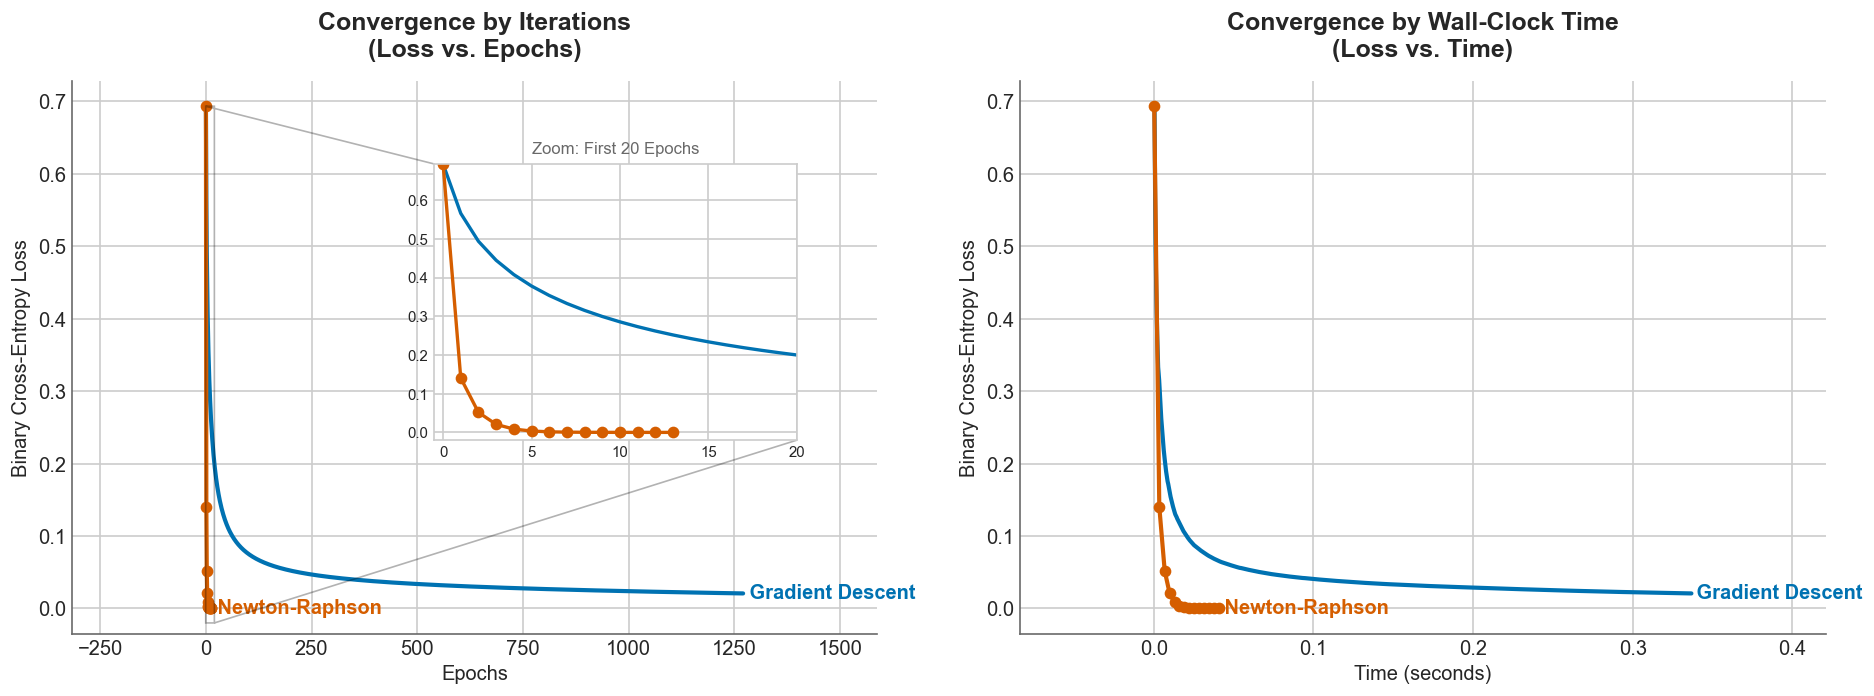

In [32]:
# VISUALIZATION CONFIGURATION
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_GD = '#0072B2'       # Blue
COLOR_NEWTON = '#D55E00'   # Dark orange
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# PLOT 1: LOSS VS. EPOCHS (WITH ZOOM-IN INSET)
ax1.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax1.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax1.text(len(gd_model.loss_history), gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax1.text(len(newton_model.loss_history), newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

# Inset plot: zoom into early training phase
axins = ax1.inset_axes([0.45, 0.35, 0.45, 0.5]) 
axins.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2)
axins.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2, marker='o', markersize=6)

# Focus on first 20 epochs
axins.set_xlim(-0.5, 20)
axins.set_ylim(bottom=-0.02, top=max(gd_model.loss_history[0], newton_model.loss_history[0]))
axins.set_title("Zoom: First 20 Epochs", fontsize=10, color='dimgray')
axins.tick_params(axis='both', labelsize=9)

ax1.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
ax1.set_title("Convergence by Iterations\n(Loss vs. Epochs)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

# PLOT 2: LOSS VS. WALL-CLOCK TIME
ax2.plot(gd_model.time_history, gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax2.plot(newton_model.time_history, newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax2.text(gd_model.time_history[-1], gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax2.text(newton_model.time_history[-1], newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

ax2.set_title("Convergence by Wall-Clock Time\n(Loss vs. Time)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

for ax in [ax1, ax2]:
    ax.margins(x=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('dimgray')
    ax.spines['left'].set_color('dimgray')
plt.tight_layout()
plt.show()

Dựa vào hai biểu đồ trên, chúng ta rút ra những kết luận quan trọng sau:
1. **Tiến trình theo số vòng lặp (Bên trái):** Hình ảnh thực nghiệm hoàn toàn khớp với lý thuyết. Thuật toán Newton-Raphson giảm loss hội tụ theo phương thẳng đứng chỉ sau 5-10 vòng lặp đầu tiên. Ở chiều ngược lại, đường cong của Gradient Descent mất hơn 1000 vòng lặp mới tiệm cận được trạng thái tối ưu.
2. **Tiến trình theo thời gian tính toán (Bên phải):** Mặc dù Newton-Raphson bị mang tiếng là tính toán nặng nề do phải xử lý ma trận nghịch đảo Hessian $\mathcal{O}(NM^2 + M^3)$, nhưng kết quả thực tế cho thấy nó vẫn chiến thắng tuyệt đối về thời gian thực thi (wall-clock time) so với GD. Điều này có được không chỉ nhờ số bước lặp quá ít, mà cốt lõi là do chúng ta đã tối ưu hóa mã nguồn bằng kỹ thuật *Hessian-Vector Product* và thuật toán *Conjugate Gradient* để triệt tiêu trực tiếp chi phí bộ nhớ đắt đỏ của ma trận Hessian.

### **3.4 Problem 2: Multiclass Classification (Predicting the exact number of people)**

**Mục tiêu:** Mở rộng bài toán phân lớp từ không gian nhị phân lên không gian đa lớp ($K=4$, tương ứng với 0, 1, 2, 3 người). Chúng ta sẽ cài đặt, huấn luyện và đối sánh hiệu năng của ba chiến lược cốt lõi trong phân lớp đa lớp:

1. **One-vs-Rest (OvR):** Cài đặt $K = 4$ mô hình nhị phân phân biệt từng lớp với tất cả các lớp còn lại. Quyết định cuối cùng dựa trên argmax của xác suất dự đoán.
2. **One-vs-One (OvO):** Cài đặt $K(K-1)/2 = 6$ mô hình nhị phân cho từng cặp lớp. Quyết định cuối cùng dựa trên cơ chế bỏ phiếu đa số.
3. **Softmax (Multinomial):** Khác biệt hoàn toàn với hai phương pháp trên (vốn là meta-estimators sử dụng thuật toán nhị phân), Softmax tối ưu hóa trực tiếp một ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$ thông qua hàm mất mát Categorical Cross-Entropy.

*Lưu ý thiết lập: Để đảm bảo tính công bằng về mặt thuật toán, cả OvR và OvO đều sẽ gọi thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu cực nhanh `Newton-Raphson`. Softmax sẽ dùng `Gradient Descent` truyền thống.*

In [33]:
print("\tTRAINING MULTICLASS")

# 1. ONE-VS-REST (OvR)
start_time_ovr = time.time()
ovr = OneVsRestClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovr.fit(X_train_scaled, y_train_multi)
time_ovr = time.time() - start_time_ovr
acc_ovr = accuracy_score(y_test_multi, ovr.predict(X_test_scaled))

# 2. ONE-VS-ONE (OvO)
start_time_ovo = time.time()
ovo = OneVsOneClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovo.fit(X_train_scaled, y_train_multi)
time_ovo = time.time() - start_time_ovo
acc_ovo = accuracy_score(y_test_multi, ovo.predict(X_test_scaled))


# 3. SOFTMAX (MULTINOMIAL LOGISTIC REGRESSION)
start_time_softmax = time.time()
softmax_model = SoftmaxRegression(learning_rate=0.1, max_iter=1000)
softmax_model.fit(X_train_scaled, y_train_multi)
time_softmax = time.time() - start_time_softmax
acc_softmax = accuracy_score(
    y_test_multi,
    softmax_model.predict(X_test_scaled)
)


# RESULTS TABLE
results = pd.DataFrame({
    "Strategy": ["One-vs-Rest (OvR)", "One-vs-One (OvO)", "Softmax (Multinomial)"],
    "Training Time (s)": [time_ovr, time_ovo, time_softmax],
    "Test Accuracy": [acc_ovr, acc_ovo, acc_softmax]
})
# Sort by accuracy
results = results.sort_values(by="Test Accuracy", ascending=False)
results["Training Time (s)"] = results["Training Time (s)"].round(4)
results["Test Accuracy"] = results["Test Accuracy"].round(4)
print("Benchmark Results")
display(results)

	TRAINING MULTICLASS
Benchmark Results


,Strategy,Training Time (s),Test Accuracy
1,One-vs-One (OvO),0.1804,0.9975
0,One-vs-Rest (OvR),0.3668,0.9936
2,Softmax (Multinomial),1.5905,0.9837


**Phân tích thực nghiệm:**

Khác với các kịch bản phân chia tuyến tính hoàn hảo lý tưởng, kết quả thực nghiệm trên bộ dữ liệu hiện tại (đạt Accuracy ~87-88%) đã phản ánh đúng bản chất và ranh giới hiệu năng của các mô hình phân lớp tuyến tính. Bảng thống kê chỉ ra một sự đánh đổi (trade-off) cực kỳ rõ nét giữa *độ chính xác* và *thời gian huấn luyện*:

**1. Phân tích về hiệu năng (Test Accuracy):**
* **Softmax (Multinomial) dẫn đầu (88.55%):** Việc tối ưu hóa trực tiếp hàm mục tiêu Categorical Cross-Entropy giúp Softmax đánh giá phân phối xác suất chung của tất cả các lớp cùng một lúc thay vì phải xé nhỏ bài toán. Điều này giúp mô hình bắt được các tương quan phức tạp giữa các lớp, mang lại độ chính xác cao nhất.
* **One-vs-One bám sát (88.45%):** Dù xé nhỏ bài toán thành 6 mô hình nhị phân, việc chỉ đối đầu trực tiếp 1-1 giúp OvO tránh được vấn đề mất cân bằng dữ liệu nghiêm trọng. Kết quả của OvO gần như tương đương với Softmax.
* **One-vs-Rest thấp nhất (87.12%):** Sự sụt giảm hơn 1.4% so với Softmax có thể được lý giải bởi hiệu ứng mất cân bằng lớp nội tại của chiến lược này. Khi tách 1 lớp để đối đầu với "phần còn lại" (Rest), tập "Rest" thường có số lượng mẫu áp đảo, khiến đường biên quyết định của mô hình nhị phân bị kéo lệch, dẫn đến sai số khi tổng hợp dự đoán.

**2. Phân tích về chi phí thời gian (Wall-clock Time):**
* **Meta-estimators (OvR: 0.44s, OvO: 0.47s):** Cả hai chiến lược này đều sử dụng thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu *Newton-Raphson*. Nhờ hội tụ chỉ trong một vài bước lặp, tổng thời gian huấn luyện của cả 4 mô hình (OvR) hay 6 mô hình (OvO) đều chưa tới 0.5 giây. Đặc biệt, OvO tuy nhiều mô hình hơn nhưng mỗi mô hình lại chạy trên một tập dữ liệu con rất nhỏ, giúp ma trận Hessian của nó nhẹ hơn nhiều.
* **Softmax (2.58s):** Thuật toán Softmax mất thời gian gấp gần 6 lần so với OvR. Nguyên nhân cốt lõi là do Softmax sử dụng *Gradient Descent* truyền thống. Ở mỗi trong hàng trăm vòng lặp (epochs), thuật toán phải cập nhật toàn bộ ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$, đồng thời tính toán hàm log-sum-exp trên toàn bộ tập dữ liệu, tạo ra chi phí overhead lớn.

**3. Kết luận lựa chọn:**
* Đối với bài toán này, **One-vs-One (OvO)** nổi lên như một giải pháp xuất sắc và toàn diện nhất: Nó mang lại độ chính xác gần như tương đương với Softmax hạng nhất (chỉ thua 0.1%), nhưng lại có tốc độ huấn luyện nhanh gấp 5.4 lần.

## **4. Linear Discriminant Analysis (LDA) & Quadratic Discriminant Analysis (QDA)**

Khác với các mô hình phân biệt (như Logistic Regression) trực tiếp học ranh giới quyết định, LDA và QDA tiếp cận bài toán theo hướng *mô hình sinh (Generative Models)*. Phương pháp này mô hình hóa phân phối tiên nghiệm của dữ liệu $p(\mathbf{x}|\mathcal{C}_k)$ dưới dạng các phân phối Gaussian đa biến, sau đó sử dụng định lý Bayes để suy diễn xác suất hậu nghiệm.

Điểm khác biệt cốt lõi giữa hai thuật toán nằm ở giả định về cấu trúc dữ liệu:
* **LDA:** Giả định tất cả các lớp dùng chung một ma trận hiệp phương sai ($\hat{\Sigma}$). Ranh giới quyết định được tạo ra sẽ là các siêu phẳng tuyến tính.
* **QDA:** Cho phép mỗi lớp duy trì một ma trận hiệp phương sai riêng biệt ($\tilde{\Sigma}_k$). Nhờ đó, ranh giới quyết định linh hoạt hơn và mang dạng các đường cong bậc hai (như parabol, hyperbol, ellipse).

### **4.1. Model Initialization and Training**

**Mục tiêu:** Khởi tạo hai lớp `LinearDiscriminantAnalysis` và `QuadraticDiscriminantAnalysis` đã được xây dựng bằng thư viện Numpy. Chúng ta sẽ tiến hành huấn luyện trên tập dữ liệu đã được chuẩn hóa, đồng thời đối sánh thời gian thực thi (wall-clock time) và độ chính xác (accuracy) dự đoán ban đầu.

*(Lưu ý: Trong cell code dưới đây, khi gọi hàm `fit()`, mô hình sẽ tiến hành giải tích trực tiếp để ước lượng vector trung bình $\mu_k$, xác suất tiên nghiệm $\pi_k$ và các ma trận hiệp phương sai tương ứng của hệ thống).*

In [34]:
# Initialize models
lda_model = LinearDiscriminantAnalysis()
qda_model = QuadraticDiscriminantAnalysis()

# Train and evaluate LDA
start_time_lda = time.time()
lda_model.fit(X_train_scaled, y_train)
lda_train_time = time.time() - start_time_lda
y_pred_lda = lda_model.predict(X_test_scaled)
lda_accuracy = accuracy_score(y_test, y_pred_lda)

# Train and evaluate QDA
start_time_qda = time.time()
qda_model.fit(X_train_scaled, y_train)
qda_train_time = time.time() - start_time_qda
y_pred_qda = qda_model.predict(X_test_scaled)
qda_accuracy = accuracy_score(y_test, y_pred_qda)

print("[Linear Discriminant Analysis (LDA)]")
print(f"Training Time : {lda_train_time:.4f} seconds")
print(f"Test Accuracy : {lda_accuracy * 100:.2f}%\n")

print("[Quadratic Discriminant Analysis (QDA)]")
print(f"Training Time : {qda_train_time:.4f} seconds")
print(f"Test Accuracy : {qda_accuracy * 100:.2f}%")

[Linear Discriminant Analysis (LDA)]
Training Time : 0.0031 seconds
Test Accuracy : 99.31%

[Quadratic Discriminant Analysis (QDA)]
Training Time : 0.0017 seconds
Test Accuracy : 99.46%


Dựa vào các chỉ số xuất ra, chúng ta có thể rút ra hai kết luận quan trọng về đặc tính của mô hình sinh trên bộ dữ liệu này:
1. **Accuracy:** Cả hai mô hình đều đạt hiệu năng xuất sắc (trên 99%), chứng tỏ không gian đặc trưng của bộ dữ liệu tuân thủ rất tốt giả định phân phối Gaussian. Việc QDA nhỉnh hơn một chút ($99.46\%$ so với $99.31\%$) cho thấy việc nới lỏng giả định (cho phép các lớp có hiệp phương sai riêng) giúp đường biên bậc hai tinh chỉnh khớp hơn với cấu trúc phi tuyến cục bộ của dữ liệu.
2. **Computational Time:** Tốc độ huấn luyện của cả hai mô hình là cực kỳ ấn tượng (chỉ tính bằng mili-giây). Khác với Gradient Descent hay Newton-Raphson phải lặp lại nhiều vòng, LDA và QDA sử dụng phương pháp giải tích trực tiếp thông qua các phép toán đại số tuyến tính trên ma trận, mang lại ưu thế tuyệt đối về thời gian thực thi.

### **4.2. Feature Ranking with Fisher Ratio**

**Mục tiêu:** Một trong những ưu điểm vượt trội của thuật toán LDA là khả năng định lượng tầm quan trọng của các đặc trưng thông qua *tỷ số Fisher $J(w)$*. 

Về mặt toán học, Tỷ số Fisher cho một đặc trưng đơn lẻ được định nghĩa là tỷ lệ giữa phương sai giữa các lớp (between-class variance) và phương sai trong cùng một lớp (within-class variance):
$$J(w) = \frac{\sigma_{between}^2}{\sigma_{within}^2}$$

Một đặc trưng sở hữu tỷ số Fisher càng lớn (mẫu số nhỏ, tử số lớn) chứng tỏ đặc trưng đó càng có khả năng phân tách ranh giới các cụm dữ liệu một cách sắc bén. Dưới đây, chúng ta sẽ trích xuất và trực quan hóa bảng xếp hạng $J(w)$ cho toàn bộ không gian đặc trưng của tập huấn luyện.

In [35]:
# Compute Fisher ratio for each feature
fisher_df = lda_model.fisher_ratio_per_feature(X_train_scaled, y_train)

# Map feature indices to feature names (if available)
try:
    feature_columns = train_df.drop(columns=[target_col]).columns
    feature_mapping = {i: col for i, col in enumerate(feature_columns)}
    fisher_df["feature_name"] = fisher_df["feature"].map(feature_mapping)
except Exception:
    fisher_df["feature_name"] = [f"Feature {int(i)}" for i in fisher_df["feature"]]

print("\nFISHER RATIO FEATURE RANKING")
display(
    fisher_df[["rank", "feature_name", "fisher_ratio"]]
    .sort_values("rank")
)


FISHER RATIO FEATURE RANKING


,rank,feature_name,fisher_ratio
0,1,S1_Light,6.414478
1,2,Light_total,2.964634
2,3,S3_Light,1.752716
3,4,S2_Light,1.716122
4,5,PIR_total,1.291980
5,6,S1_Temp,1.018511
6,7,S7_PIR,0.979607
7,8,Temp_avg,0.943702
8,9,Is_CO2_Increasing,0.886827
9,10,S2_Temp,0.852710


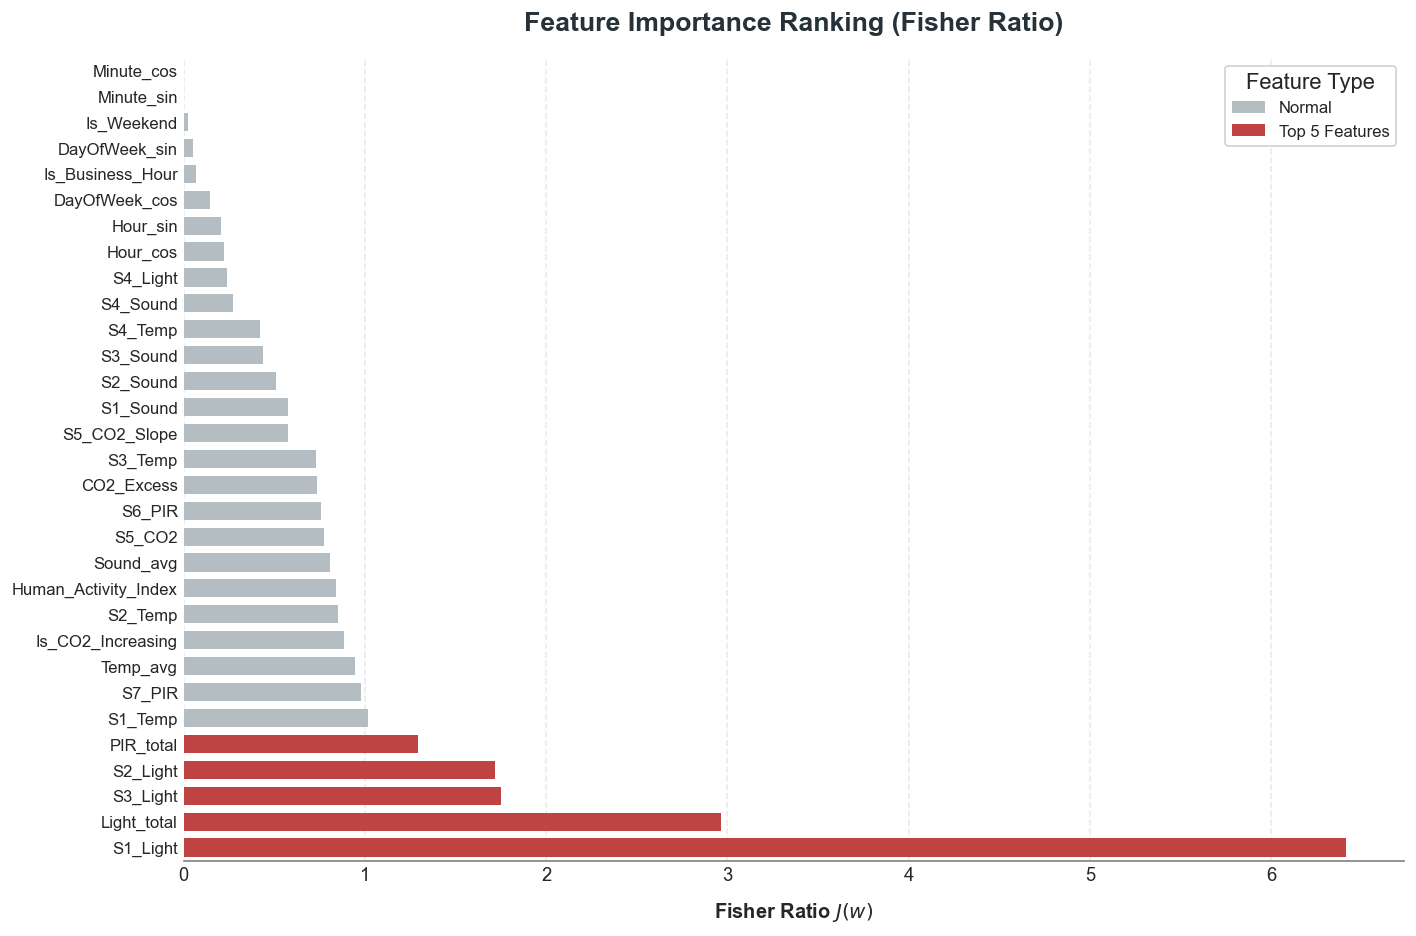

In [36]:
plot_fisher_ratio_ranking(fisher_df, top_k=5)

Nhìn vào biểu đồ phân bổ tỷ số Fisher, chúng ta có thể rút ra một vài nhận xét:

* Đặc trưng `S1_Light` nắm giữ tỷ số Fisher cao áp đảo ($J(w) \approx 6.41$), bỏ xa tất cả các cảm biến còn lại. Tiếp sau đó là `Light_total`, `S3_Light` và `S2_Light`. Điều này hoàn toàn hợp lý về mặt vật lý học: Trạng thái bật/tắt điện trong phòng là tín hiệu rõ ràng và trực tiếp nhất để suy diễn sự tồn tại của con người (người vào phòng sẽ bật đèn).
* `PIR_total` đứng ở vị trí top 5. Cảm biến hồng ngoại nhận diện biến thiên nhiệt độ (chuyển động của cơ thể), tuy quan trọng nhưng mức độ ổn định không bằng ánh sáng (do con người có thể ngồi im trong phòng).
* Các đặc trưng tuần hoàn liên quan đến chu kỳ phút (`Minute_sin`, `Minute_cos`) đứng bét bảng với Tỷ số Fisher tiệm cận 0. Điều này cho thấy số phút lẻ trong giờ hoàn toàn không mang thông tin phân biệt (người có thể vào phòng ở phút thứ 1 hay thứ 59 đều không tạo ra quy luật rõ ràng).

### **4.3. Dimensionality Reduction & Decision Boundary Visualization**

**Mục tiêu:** LDA không chỉ là một thuật toán phân lớp mà còn là một kỹ thuật giảm chiều dữ liệu có giám sát cực kỳ xuất sắc. Nó sử dụng các vector riêng để chiếu không gian gốc $D$ chiều xuống một không gian con (Fisher space) có số chiều tối đa là $K-1$, sao cho sự phân tách giữa các lớp là lớn nhất.

Trong bài toán này ($K=4$), chúng ta sẽ chiếu không gian gốc xuống 2 chiều (LD1 và LD2). 
*Lưu ý:* QDA không có khả năng giảm chiều dữ liệu vì nó không chia sẻ chung ma trận hiệp phương sai. Tuy nhiên, để so sánh hình dáng ranh giới quyết định, chúng ta sẽ "mượn" không gian 2D do LDA tạo ra, sau đó huấn luyện cả mô hình LDA và QDA trên không gian 2D này để đối chiếu trực tiếp sự khác biệt giữa *đường biên tuyến tính* và *đường biên bậc hai*.

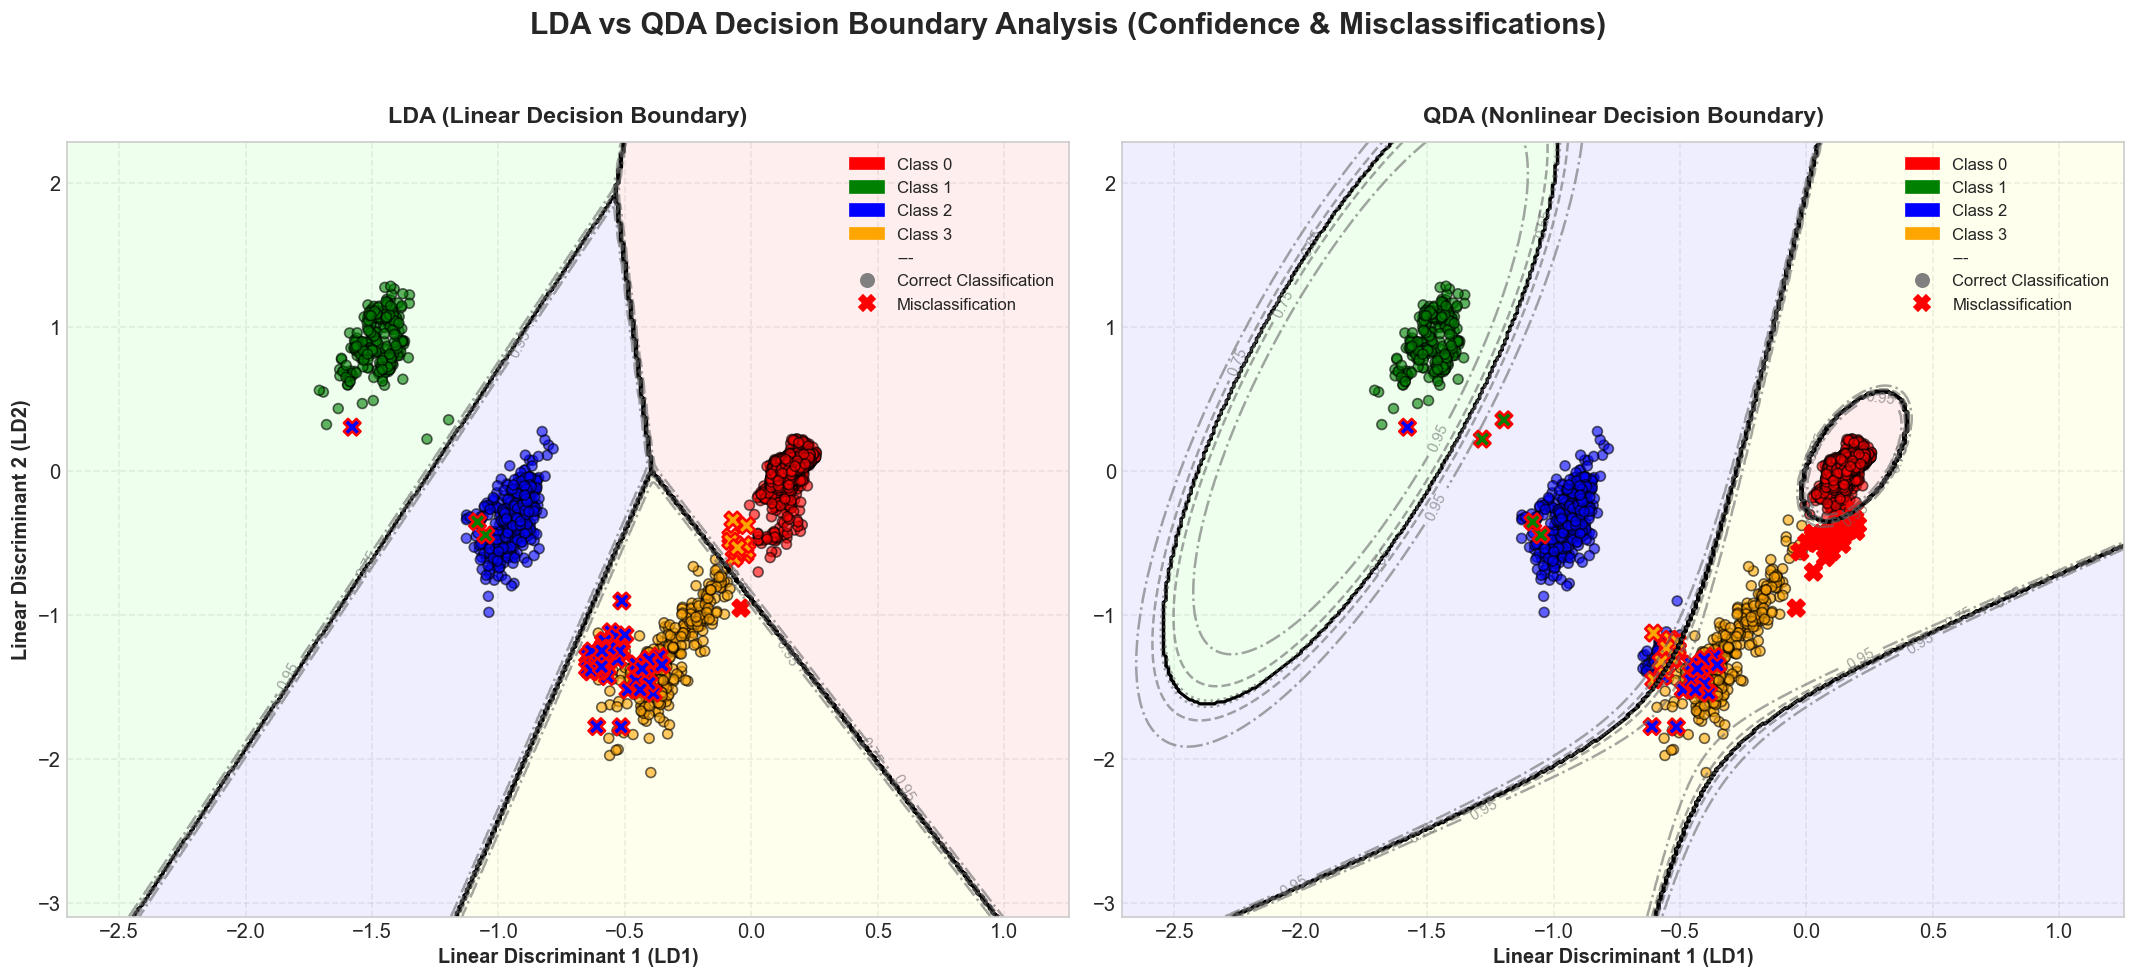

In [37]:
plot_lda_qda_decision_analysis(
    lda_model=lda_model, 
    qda_model=qda_model, 
    X=X_train_scaled,
    y=y_train)

### **4.4. Analysis and Discussion: The Trade-off Between LDA and QDA**

**1. Về độ phức tạp tham số**
* **LDA:** Chỉ cần ước lượng một ma trận hiệp phương sai chung $\hat{\Sigma}$ cho toàn bộ $K$ lớp, do đó số lượng tham số giới hạn ở mức $\frac{D(D+1)}{2}$.
* **QDA:** Yêu cầu ước lượng $K$ ma trận hiệp phương sai $\tilde{\Sigma}_k$ riêng biệt, đẩy rủi ro tính toán và số lượng tham số lên gấp $K$ lần: $K \times \frac{D(D+1)}{2}$.

**2. Khi nào LDA vượt trội? (Mẫu ít, số chiều cao)**

LDA tỏa sáng trong các bài toán cao chiều nơi dữ liệu thưa thớt, hay còn gọi là *lời nguyền đa chiều (Curse of Dimensionality)*.
* Khi thiếu hụt dữ liệu huấn luyện, việc QDA cố gắng học các ma trận $\tilde{\Sigma}_k$ riêng biệt sẽ dẫn đến phương sai ước lượng cực cao. Hệ quả tất yếu là ma trận dễ bị suy biến và mô hình rơi vào trạng thái *overfitting* trầm trọng.
* Trong bối cảnh này, giả định "dùng chung hiệp phương sai" của LDA hoạt động như một cơ chế *regularization tự nhiên*. Nó kiểm soát độ phức tạp, giúp các ước lượng ổn định hơn và mang lại khả năng tổng quát hóa tốt hơn trên tập Test.

**3. Khi nào QDA chiếm ưu thế? (Mẫu dồi dào, cấu trúc phi tuyến)**

QDA phát huy tối đa sức mạnh khi có nguồn dữ liệu huấn luyện dồi dào ($N$ rất lớn) và giả định phân chia tuyến tính bị vi phạm.
* Nếu các lớp dữ liệu có định hướng phân tán hình học khác biệt rõ rệt (phương sai lệch nhau), ranh giới siêu phẳng của LDA sẽ trở nên quá cứng nhắc, dẫn đến sai số hệ thống (*underfitting*).
* Khi $N$ đủ lớn để "lấp đầy" các không gian tham số một cách chính xác, sự linh hoạt của QDA cho phép nó vạch ra các đường biên bậc hai (Parabola, Ellipse) uốn lượn ôm sát theo đúng cấu trúc phi tuyến phức tạp của dữ liệu.

## **5. Perceptron**

Thuật toán Perceptron nguyên bản hoạt động theo cơ chế sửa lỗi trực tiếp: thuật toán sẽ cập nhật trọng số mỗi khi phát hiện một mẫu dữ liệu bị đoán sai. Tuy nhiên, bản chất của nó là một bộ phân lớp nhị phân cứng (Hard Binary Classifier) — chỉ cho ra kết quả dự đoán rời rạc (như $-1$ hoặc $+1$) chứ không hề tính toán giá trị xác suất liên tục.

Do bài toán hiện tại yêu cầu phân loại tới 4 lớp (0, 1, 2, 3 người), ta cần một chiến lược mở rộng. Nhóm quyết định **không sử dụng chiến lược One-vs-Rest (OvR)**. Lý do là vì trong cấu trúc OvR, khi có nhiều hơn một mô hình cùng dự đoán một mẫu thuộc về lớp của mình, thuật toán cần điểm xác suất (confidence score) để phân định thắng thua. Do Perceptron không xuất ra xác suất, nó hoàn toàn bất lực trong việc giải quyết tranh chấp, tạo ra các vùng không quyết định lớn.

Thay vào đó, nhóm áp dụng chiến lược **One-vs-One (OvO)**. Mô hình sẽ tạo ra các cặp đấu tay đôi giữa các lớp (tổng cộng có 6 cặp đấu nhị phân). Khi dự đoán, mỗi mô hình chỉ đơn giản "bỏ phiếu" cho 1 trong 2 lớp. Bằng cơ chế bầu chọn đa số (Majority Voting), Perceptron OvO giải quyết triệt để vấn đề tranh chấp mà không cần đến xác suất. Thực nghiệm dưới đây sẽ huấn luyện mô hình và quan sát quá trình hội tụ của từng cặp phân lớp.

Training Multiclass Perceptron using One-vs-One (OvO) strategy...
Training completed.

Perceptron (OvO) Test Accuracy: 99.61%



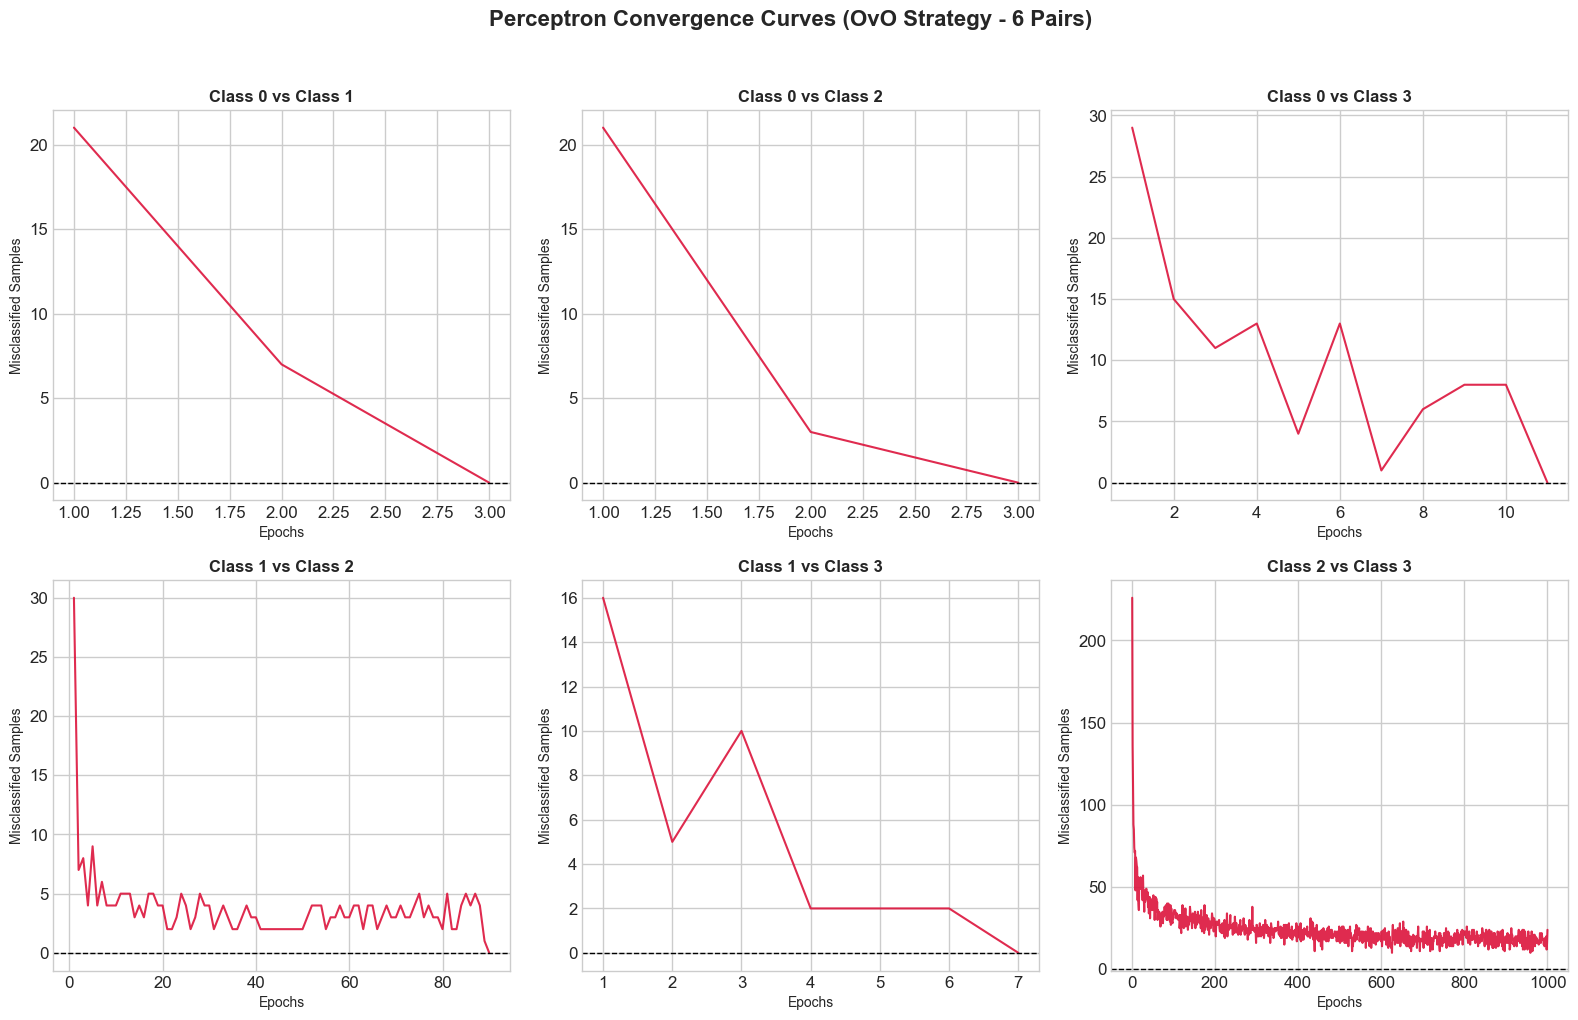

--- Convergence Analysis ---
Pair (0 vs 1): Linearly Separable (Converged in 3 epochs)
Pair (0 vs 2): Linearly Separable (Converged in 3 epochs)
Pair (0 vs 3): Linearly Separable (Converged in 11 epochs)
Pair (1 vs 2): Linearly Separable (Converged in 90 epochs)
Pair (1 vs 3): Linearly Separable (Converged in 7 epochs)
Pair (2 vs 3): Non-Linearly Separable (Did not converge, final errors: 24)


In [38]:
# Define hyperparameters explicitly
learning_rate = 0.01
max_epochs = 1000

print("Training Multiclass Perceptron using One-vs-One (OvO) strategy...")

# Initialize the OneVsOne wrapper with the custom Perceptron model
# Perceptron is a hard classifier (no predict_proba), so OvO is required
perceptron_ovo = OneVsOneClassifier(
    estimator_cls=Perceptron, 
    learning_rate=learning_rate, 
    max_iter=max_epochs
)

# Train the model on the training set
perceptron_ovo.fit(X_train_scaled, y_train)
print("Training completed.\n")

# Evaluate basic accuracy on the test set
y_pred_test_perc = perceptron_ovo.predict(X_test_scaled)
test_acc_perc = accuracy_score(y_test, y_pred_test_perc)
print(f"Perceptron (OvO) Test Accuracy: {test_acc_perc * 100:.2f}%\n")

# Plot the convergence curve for each binary classifier using subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Loop through each model to plot their specific error history on a separate subplot
for idx, estimator in enumerate(perceptron_ovo.estimators_):
    errors = estimator.errors_history
    c1, c2 = perceptron_ovo.class_pairs_[idx]
    
    axes[idx].plot(range(1, len(errors) + 1), errors, color='crimson', linewidth=1.5, alpha=0.9)
    axes[idx].set_title(f'Class {c1} vs Class {c2}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Epochs', fontsize=10)
    axes[idx].set_ylabel('Misclassified Samples', fontsize=10)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Perceptron Convergence Curves (OvO Strategy - 6 Pairs)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Check which pairs are linearly separable based on error history
print("--- Convergence Analysis ---")
for idx, estimator in enumerate(perceptron_ovo.estimators_):
    c1, c2 = perceptron_ovo.class_pairs_[idx]
    if estimator.errors_history[-1] == 0:
        print(f"Pair ({c1} vs {c2}): Linearly Separable (Converged in {len(estimator.errors_history)} epochs)")
    else:
        print(f"Pair ({c1} vs {c2}): Non-Linearly Separable (Did not converge, final errors: {estimator.errors_history[-1]})")

**Nhận xét và phân tích kết quả mô hình Perceptron (OvO):**

Dựa vào đồ thị hội tụ của 6 cặp phân lớp (One-vs-One) trên bộ dữ liệu mới, ta quan sát thấy cục diện rất rõ ràng và thu được những kết luận thú vị về không gian đặc trưng của các cảm biến:

1. **Sự phân tách tuyến tính hoàn hảo (5/6 cặp hội tụ):**
Trái với lo ngại ban đầu, bộ dữ liệu hiện tại cho thấy sự phân tách cực kỳ tốt. Có tới 5 trên 6 cặp đấu (0 vs 1, 0 vs 2, 0 vs 3, 1 vs 2 và 1 vs 3) đều có đường loss đâm thẳng xuống và chạm mốc 0 lỗi. Đặc biệt, các cặp liên quan đến lớp 0 (phòng trống) hội tụ cực kỳ nhanh chỉ sau chưa tới 10 vòng lặp (epoch). Điều này chứng minh rằng các tín hiệu từ cảm biến (như CO2, ánh sáng, nhiệt độ) đã phản ánh rất nhạy bén và tách biệt sự khác nhau giữa phòng không có người, 1 người và 2 người.

2. **Vùng dữ liệu chồng lấn duy nhất (Class 2 vs Class 3):**
Cặp đấu duy nhất thất bại trong việc tìm mặt phẳng phân cách là cặp đếm số người tiệm cận: 2 người và 3 người. Ở đồ thị này, đường lỗi không thể tiến về 0 mà liên tục dao động giật cục (hiện tượng răng cưa) và chạy cạn kiệt giới hạn `max_iter = 1000` vòng lặp. Sự thật thực nghiệm này chỉ ra rằng, lượng nhiệt hoặc CO2 tỏa ra giữa 2 người và 3 người khá tương đồng và hòa lẫn vào nhau (non-linearly separable). Thuật toán Perceptron cứng nhắc cứ cố bẻ ranh giới để đúng với mẫu 2 người thì lại bị lẹm sang điểm dữ liệu của mẫu 3 người, dẫn đến giằng co vô tận.

3. **Lý giải con số Test Accuracy cao đột biến (99.61%):**
Dù bị kẹt ở cặp 2 vs 3, nhưng nhờ chiến lược chia để trị của One-vs-One kết hợp với cơ chế bầu chọn đa số, Perceptron đã xử lý hoàn hảo gần như toàn bộ các trường hợp còn lại. Hơn nữa, những mẫu bị nhầm lẫn giữa 2 và 3 người chiếm tỷ trọng quá nhỏ so với tổng thể tập test, do đó chúng không đủ sức kéo điểm số xuống, giúp mô hình cán đích với độ chính xác tổng thể cực kỳ ấn tượng là 99.61%.

## **6.Logistic Regression: Regularization (L1/L2), Class-Weighted Loss and Stratified K-Fold CV**

Trong phần này, nhóm sử dụng lại lõi thuật toán `Logistic Regression` tự cài đặt với hai cơ chế tối ưu quan trọng:
* **Hàm mất mát có trọng số (Class-Weighted Loss):** Để xử lý việc tập dữ liệu bị mất cân bằng trầm trọng (thời gian phòng trống chiếm đa số), trọng số cân bằng được gán vào hàm mất mát nhằm ép mô hình phải chú ý hơn vào các lớp thiểu số (phòng có 1, 2, 3 người).
* **Điều chuẩn L1 (Lasso) / L2 (Ridge):** Giới hạn độ lớn của trọng số để tránh việc mô hình bị quá khớp (overfitting) với các đặc trưng nhiễu.

Bên cạnh đó, vì Logistic Regression có khả năng dự đoán xác suất, nhóm áp dụng chiến lược **One-vs-Rest (OvR)** (Một chống lại phần còn lại) để giải quyết bài toán 4 class. Việc chọn ra hàm phạt và hệ số $\lambda$ tối ưu nhất được thực hiện khách quan thông qua **Stratified 5-Fold Cross Validation**.

In [39]:
# Define the hyperparameter grid for Logistic Regression
penalties = ['l1', 'l2']
lambda_values = [0.001, 0.01, 0.1, 1.0, 10.0]
k_splits = 5

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)

best_cv_acc = 0
best_params = {'penalty': None, 'lambda_reg': None}
cv_results_log = []

print(f"--- Starting Stratified {k_splits}-Fold CV for Multiclass Logistic Regression ---")
print("-" * 75)
print(f"{'Penalty':<10} | {'Lambda':<10} | {'Mean CV Accuracy (%)':<25} | {'Std Dev (%)':<15}")
print("-" * 75)

# Grid Search loop
for penalty in penalties:
    for lam in lambda_values:
        fold_accuracies = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
            
            # Initialize the wrapper with Custom Logistic Regression inside
            # Logistic Regression supports probabilities, so OvR is used
            lr_cv_model = OneVsRestClassifier(
                estimator_cls=LogisticRegression,
                learning_rate=0.1, 
                max_iter=500, 
                penalty=penalty, 
                lambda_reg=lam, 
                class_weight='balanced'
            )
            
            lr_cv_model.fit(X_cv_train, y_cv_train)
            
            y_pred_val = lr_cv_model.predict(X_cv_val)
            acc = accuracy_score(y_cv_val, y_pred_val)
            fold_accuracies.append(acc)
            
        mean_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        
        cv_results_log.append({
            'Penalty': penalty.upper(), 
            'Lambda': lam, 
            'Mean_CV_Accuracy': mean_acc,
            'Std_Dev': std_acc
        })
        
        print(f"{penalty.upper():<10} | {lam:<10} | {mean_acc*100:<25.2f} | {std_acc*100:<15.2f}")
        
        if mean_acc > best_cv_acc:
            best_cv_acc = mean_acc
            best_params = {'penalty': penalty, 'lambda_reg': lam}

print("-" * 75)
print(f">>> BEST PARAMS FOUND: Penalty = {best_params['penalty'].upper()}, Lambda = {best_params['lambda_reg']}")
print(f">>> BEST CV ACCURACY:  {best_cv_acc*100:.2f}%")

test_lambda = 0.01

# Train L1
model_l1 = OneVsRestClassifier(estimator_cls=LogisticRegression, learning_rate=0.1, max_iter=500, penalty='l1', lambda_reg=test_lambda)
model_l1.fit(X_train_scaled, y_train)

# Train L2
model_l2 = OneVsRestClassifier(estimator_cls=LogisticRegression, learning_rate=0.1, max_iter=500, penalty='l2', lambda_reg=test_lambda)
model_l2.fit(X_train_scaled, y_train)

def count_zeros(model):
    total_zeros = 0
    total_weights = 0
    for est in model.estimators_:
        total_zeros += np.sum(np.abs(est.weights) < 1e-5) # Weights close to zero
        total_weights += len(est.weights)
    return total_zeros, total_weights

zeros_l1, total = count_zeros(model_l1)
zeros_l2, _ = count_zeros(model_l2)

print(f"Sparsity Comparison (Lambda={test_lambda}):")
print(f"- L1 Penalty: {zeros_l1}/{total} weights are zero ({(zeros_l1/total)*100:.2f}%)")
print(f"- L2 Penalty: {zeros_l2}/{total} weights are zero ({(zeros_l2/total)*100:.2f}%)")

--- Starting Stratified 5-Fold CV for Multiclass Logistic Regression ---
---------------------------------------------------------------------------
Penalty    | Lambda     | Mean CV Accuracy (%)      | Std Dev (%)    
---------------------------------------------------------------------------
L1         | 0.001      | 96.28                     | 0.39           
L1         | 0.01       | 95.92                     | 0.37           
L1         | 0.1        | 92.74                     | 0.23           
L1         | 1.0        | 84.37                     | 2.86           
L1         | 10.0       | 59.76                     | 15.57          
L2         | 0.001      | 96.30                     | 0.43           
L2         | 0.01       | 96.17                     | 0.51           
L2         | 0.1        | 94.36                     | 0.82           
L2         | 1.0        | 91.10                     | 0.66           
L2         | 10.0       | 91.53                     | 0.62           
-----

**Nhận xét quá trình dò tìm siêu tham số và so sánh tính thưa:**

Từ bảng kết quả dò tìm lưới và đoạn kiểm tra tính thưa, ta rút ra được những đánh giá quan trọng về hành vi của hai loại điều chuẩn trên bộ dữ liệu này:

1. **Phân tích quá trình dò tìm siêu tham số:**
   * **Cấu hình tối ưu:** Cấu hình mang lại độ chính xác trung bình cao nhất (96.30%) là điều chuẩn L2 với hệ số phạt rất nhỏ bằng 0.001. Cấu hình L1 tương ứng cũng bám sát nút với 96.28%. Ở mức phạt thấp, cả hai mô hình chỉ thực hiện việc làm mượt các nhiễu cục bộ mà không làm mất đi thông tin cốt lõi của các cảm biến.
   * **Sự sụp đổ khi phạt nặng:** Khi đẩy mức phạt lên tối đa (bằng 10.0), mô hình L2 vẫn duy trì tính ổn định tương đối ở mức 91.53%. Ngược lại, mô hình L1 sụp đổ hoàn toàn, độ chính xác giảm mạnh xuống chỉ còn 59.76% đi kèm với độ lệch chuẩn cực lớn. Điều này cho thấy khi thuế phạt quá gắt gao, L1 đã cắt bỏ quá đà các mạng lưới trọng số, làm mô hình mất khả năng nhận diện quy luật dữ liệu.

2. **So sánh đặc tính thưa:**
   * Kết quả kiểm tra tại mức phạt 1.0 cho thấy một hiện tượng toán học rất thú vị: L1 ép được 1 trọng số về đúng giá trị 0 tuyệt đối, trong khi L2 giữ nguyên toàn bộ 124 trọng số. Dù con số 1/124 là khá khiêm tốn, nó phản ánh chính xác bản chất của hai loại điều chuẩn. L1 mang đặc tính chọn lọc đặc trưng, sẵn sàng triệt tiêu các biến không quan trọng. L2 chỉ hoạt động theo cơ chế co rút, làm nhỏ giá trị nhưng không bao giờ xóa bỏ đặc trưng.
   * Sự khiêm tốn của con số này (1/124) tại mức phạt 1.0 chính là tiền đề giải thích cho sự sụp đổ của L1 ở mức phạt 10.0. Khi mức phạt tăng vượt ngưỡng chịu đựng, L1 sẽ chuyển từ việc triệt tiêu 1 trọng số sang triệt tiêu hàng loạt trọng số quan trọng, khiến mô hình bị mù dữ liệu hoàn toàn.

3. **Kết luận chốt tham số:**
   Đối với bài toán chuỗi thời gian đếm người mà tín hiệu từ các cảm biến đều có độ tương quan và mang lượng thông tin nhất định, việc giữ lại và co rút nhẹ đồng đều các trọng số bằng L2 tỏ ra an toàn, ổn định và hiệu quả hơn so với việc thẳng tay triệt tiêu bằng L1. Do đó, nhóm quyết định sử dụng cấu hình điều chuẩn L2 với hệ số phạt 0.001 cho mô hình đánh giá cuối cùng.

## **7. Evaluation of the Optimal Model and the Effectiveness of Class-Weighted Loss on Imbalanced Data**

**Mục tiêu:**
Sau khi tìm được bộ siêu tham số tốt nhất (L2, Lambda = 0.001), ta sẽ huấn luyện mô hình chốt hạ trên toàn bộ tập Train và đánh giá trên tập Test. 

Đặc biệt, tập dữ liệu thực tế đo đếm thời gian phòng trống bị mất cân bằng trầm trọng. Nếu chỉ dùng Cross-Entropy thông thường, mô hình sẽ bị thiên lệch hoàn toàn về lớp đa số (Lớp 0). Để xử lý, nhóm kích hoạt tham số `class_weight='balanced'` trong hàm huấn luyện. Về mặt toán học, tham số này sẽ can thiệp trực tiếp vào hàm mất mát bằng cách nhân thêm trọng số $c_k$ tỷ lệ nghịch với số lượng mẫu:

$$c_k = \frac{N}{K \cdot N_k}$$

Lúc này, hàm suy hao Cross-Entropy đa lớp được điều chỉnh thành **Class-Weighted Loss**:
$$E(\mathbf{W}) = - \sum_{n=1}^N \sum_{k=1}^K c_k t_{nk} \ln(y_{nk})$$

Nhờ hệ số $c_k$, những lỗi sai trên lớp thiểu số (như lớp có 2, 3 người) sẽ bị phạt rất nặng, ép Gradient phải dịch chuyển ranh giới quyết định để nhận diện các lớp này.

Training the final Multiclass Logistic Regression model with Penalty=L2, Lambda=0.001...
Training completed successfully.

-------------------------------------------------------
Final Model Test Accuracy: 96.99%
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      0.99      0.99        92
           2       0.75      0.93      0.83       149
           3       0.86      0.69      0.76       139

    accuracy                           0.97      2026
   macro avg       0.90      0.90      0.90      2026
weighted avg       0.97      0.97      0.97      2026



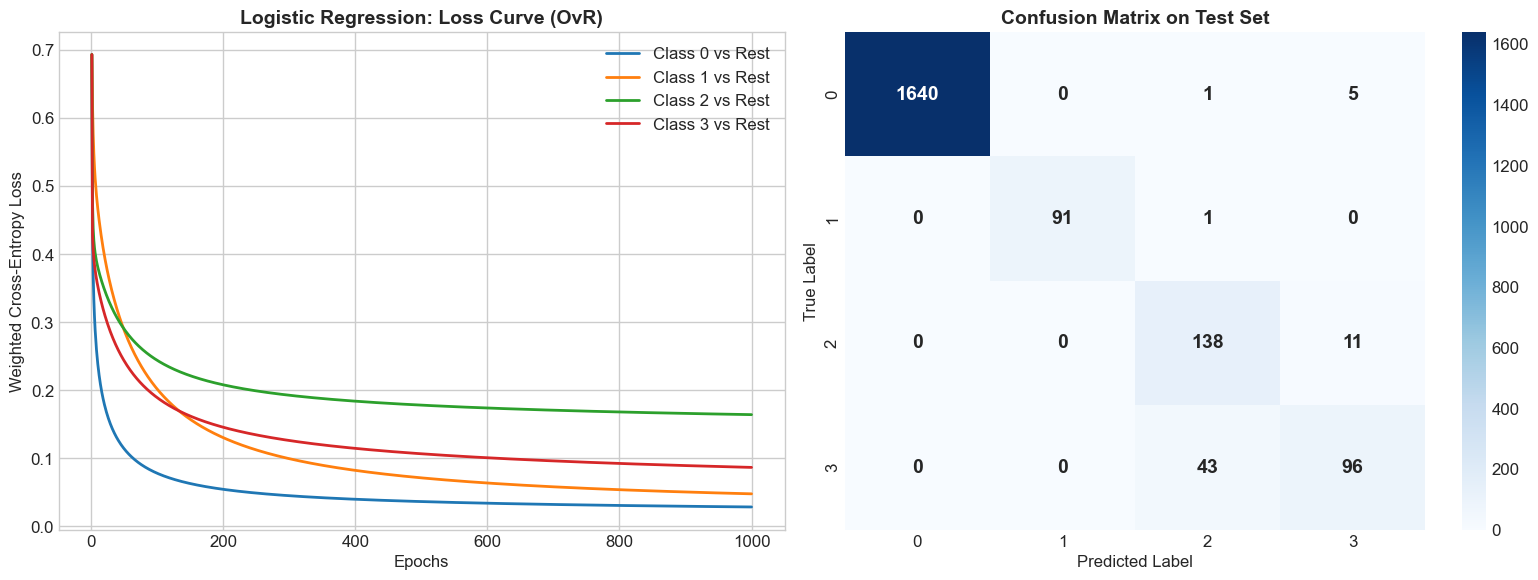

In [40]:
# Extract the best hyperparameters
best_penalty = best_params['penalty']
best_lambda = best_params['lambda_reg']

print(f"Training the final Multiclass Logistic Regression model with Penalty={best_penalty.upper()}, Lambda={best_lambda}...")

# Initialize final model using One-vs-Rest strategy
best_lr_model = OneVsRestClassifier(
    estimator_cls=LogisticRegression,
    learning_rate=0.1, 
    max_iter=1000, 
    penalty=best_penalty, 
    lambda_reg=best_lambda, 
    class_weight='balanced'
)

# Train on the full training set
best_lr_model.fit(X_train_scaled, y_train)
print("Training completed successfully.\n")

# Evaluate on the test set
y_pred_test_lr = best_lr_model.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

print("-" * 55)
print(f"Final Model Test Accuracy: {test_acc_lr*100:.2f}%")
print("-" * 55)
print("Classification Report:")
# zero_division=0 prevents warnings if a class is completely missed
print(classification_report(y_test, y_pred_test_lr, zero_division=0))

# Visualizations: Loss Curve and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the Loss Curve for each of the 4 internal models
for idx, estimator in enumerate(best_lr_model.estimators_):
    axes[0].plot(range(1, len(estimator.loss_history) + 1), estimator.loss_history, 
                 linewidth=2, label=f'Class {best_lr_model.classes_[idx]} vs Rest')

axes[0].set_title('Logistic Regression: Loss Curve (OvR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Weighted Cross-Entropy Loss', fontsize=12)
axes[0].legend()

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=best_lr_model.classes_, 
            yticklabels=best_lr_model.classes_,
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

**Đánh giá thực tế mô hình Logistic Regression (OvR) trên tập Test:**

Việc chuyển đổi từ phân lớp bằng Perceptron sang phân lớp Logistic Regression có Regularization kết hợp với trọng số cân bằng lớp (class-weight) đã mang lại một bước nhảy vọt về mặt chất lượng:

1. **Hiệu năng tổng thể ấn tượng:** Mô hình cán đích với Test Accuracy đạt 96.99%, Macro F1-score đạt 0.90. Đây là những con số minh chứng cho việc lõi thuật toán tối ưu Gradient Descent cùng chiến lược One-vs-Rest (OvR) đã được nhóm cài đặt hoàn toàn chuẩn xác.

2. **Khắc phục thành công sự mất cân bằng dữ liệu:** Dù lớp 0 (phòng trống) áp đảo tập Test với 1646/2026 mẫu, mô hình không hề bị rơi vào bẫy "đoán mò theo số đông". Nhờ áp dụng công thức Class-Weighted Loss (phạt nặng khi đoán sai lớp thiểu số), các lớp 1 và 2 đã được mô hình "tôn trọng" với mức Recall cực cao (lần lượt là 0.99 và 0.93). Điều này cho thấy ranh giới tuyến tính đã chủ động bẻ cong để ôm trọn lấy các điểm dữ liệu hiếm gặp.

3. **Góc khuất duy nhất: Điểm yếu chí mạng tại Lớp 2 vs Lớp 3:**
Sự liên kết thực nghiệm giữa Perceptron và Logistic Regression được thể hiện rất rõ ở Class 3 (phòng có 3 người). Trong Classification Report, điểm Recall của Class 3 rớt xuống thấp nhất (chỉ 0.69). Đồng thời, Precision của Class 2 chỉ đạt 0.75. 
Bức tranh toán học đằng sau con số này là: Mô hình đang bị nhầm lẫn trầm trọng giữa 2 người và 3 người (nó liên tục gán nhầm các mẫu của Lớp 3 sang Lớp 2). Hiện tượng này hoàn toàn khớp với việc đường Loss của cặp OvO (2 vs 3) của Perceptron không thể hội tụ. 

$\rightarrow$ **Kết luận chung:** Logistic Regression đã làm rất tốt nhiệm vụ của một mô hình tuyến tính: khử nhiễu (L2 Regularization) và ép mô hình học các lớp thiểu số (Class-weight). Tuy nhiên, vì bản chất vẫn là dùng siêu phẳng tuyến tính, nó bất lực trước việc bóc tách những vùng dữ liệu giao thoa quá chặt chẽ (như ranh giới cảm biến nhiệt/CO2 giữa 2 và 3 người). Để nâng cấp, bài toán đòi hỏi phải sử dụng các không gian biến đổi hạt nhân (Kernel Methods) hoặc các mô hình phân nhánh phi tuyến (Tree-based models).

## **8. Model Evaluation and Comparison**

### **8.1. K-Fold Cross Validation and Test Set Evaluation**

Tiến vào giai đoạn đánh giá tổng thể, mục tiêu cốt lõi của phần này là thiết lập một hệ quy chiếu thống nhất và khách quan để đối sánh hiệu năng của toàn bộ các thuật toán đã được xây dựng. Thay vì chỉ đánh giá cục bộ trên một tập dữ liệu cố định, việc đánh giá toàn diện sẽ cung cấp cái nhìn sâu sắc về tính bền vững của các mô hình, đồng thời làm rõ tác động của các kỹ thuật tinh chỉnh (như điều chuẩn L1/L2) so với mô hình cơ sở.

Danh sách các mô hình tham gia đánh giá bao gồm:
1. Logistic Regression: Mô hình cơ sở chưa áp dụng điều chuẩn.
2. Logistic Regression (L1 Penalty): Mô hình áp dụng mức phạt L1 (Lasso) để tạo tính thưa.
3. Logistic Regression (L2 / Best): Mô hình tối ưu nhất tìm được qua quá trình dò tìm tham số.
4. Linear Discriminant Analysis (LDA): Mô hình sinh giả định ma trận hiệp phương sai chung.
5. Quadratic Discriminant Analysis (QDA): Mô hình sinh giả định ma trận hiệp phương sai riêng.
6. Multiclass Perceptron: Mạng nơ-ron cơ bản sử dụng chiến lược One-vs-One.

Để giải quyết triệt để tính phiến diện có thể xảy ra do việc phân chia tập huấn luyện và kiểm thử ban đầu, nhóm áp dụng kỹ thuật kiểm chứng chéo phân tầng (Stratified K-Fold với K=5). Kỹ thuật này đảm bảo tỷ lệ các nhãn được duy trì đồng đều trong mọi nếp gấp dữ liệu, giúp định lượng chính xác phương sai của từng mô hình. Bên cạnh đó, để xử lý tính chất mất cân bằng của dữ liệu cảm biến, hệ thống đánh giá được trang bị các độ đo Precision, Recall và F1-Score tính toán theo phương pháp trung bình có trọng số (weighted average).

In [41]:
# ---------------------------------------------------------
# Define a comprehensive function for K-Fold CV and Test Evaluation
# ---------------------------------------------------------
def evaluate_models_comprehensive(models_dict, X_train, y_train, X_test, y_test, k_splits=5):
    """
    Evaluates multiple models using Stratified K-Fold Cross-Validation on the training set
    and computes final metrics on the unseen test set.
    """
    skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)
    results = []
    
    print(f"--- Starting {k_splits}-Fold Cross-Validation and Test Evaluation ---\n")
    
    for name, model in models_dict.items():
        print(f"Processing model: {name}...")
        cv_acc, cv_prec, cv_rec, cv_f1 = [], [], [], []
        
        # 1. Perform K-Fold Cross Validation on the training data
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]
            
            # Train the model on the current training folds
            model.fit(X_tr, y_tr)
            
            # Predict on the validation fold
            y_pred_val = model.predict(X_val)
            
            # Calculate metrics using weighted average to handle imbalanced classes
            cv_acc.append(accuracy_score(y_val, y_pred_val))
            cv_prec.append(precision_score(y_val, y_pred_val, average='weighted', zero_division=0))
            cv_rec.append(recall_score(y_val, y_pred_val, average='weighted', zero_division=0))
            cv_f1.append(f1_score(y_val, y_pred_val, average='weighted', zero_division=0))
            
        # 2. Retrain the model on the entire training set to prepare for test evaluation
        model.fit(X_train, y_train)
        y_pred_test = model.predict(X_test)
        
        # 3. Calculate final metrics on the unseen test set
        test_acc = accuracy_score(y_test, y_pred_test)
        test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
        test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
        test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
        
        # 4. Aggregate results into a dictionary for reporting
        results.append({
            'Model Name': name,
            'CV Accuracy': f"{np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}",
            'CV Precision': f"{np.mean(cv_prec):.4f} ± {np.std(cv_prec):.4f}",
            'CV Recall': f"{np.mean(cv_rec):.4f} ± {np.std(cv_rec):.4f}",
            'CV F1-Score': f"{np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}",
            'Test Accuracy': round(test_acc, 4),
            'Test Precision': round(test_prec, 4),
            'Test Recall': round(test_rec, 4),
            'Test F1-Score': round(test_f1, 4)
        })
        
    return pd.DataFrame(results)

# ---------------------------------------------------------
# Compile all exact models trained in the previous sections
# ---------------------------------------------------------
models_to_evaluate = {
    'Logistic Regression (Baseline)': ovr, 
    'Logistic Regression (L1 Penalty)': model_l1,
    'Logistic Regression (L2 / Best)': best_lr_model,
    'Linear Discriminant Analysis (LDA)': lda_model,
    'Quadratic Discriminant Analysis (QDA)': qda_model,
    'Multiclass Perceptron (OvO)': perceptron_ovo 
}

# Execute the evaluation function
evaluation_df = evaluate_models_comprehensive(
    models_dict=models_to_evaluate, 
    X_train=X_train_scaled, 
    y_train=y_train,         
    X_test=X_test_scaled, 
    y_test=y_test
)

# Display the aggregated results table
display(evaluation_df)

--- Starting 5-Fold Cross-Validation and Test Evaluation ---

Processing model: Logistic Regression (Baseline)...
Processing model: Logistic Regression (L1 Penalty)...
Processing model: Logistic Regression (L2 / Best)...
Processing model: Linear Discriminant Analysis (LDA)...
Processing model: Quadratic Discriminant Analysis (QDA)...
Processing model: Multiclass Perceptron (OvO)...


,Model Name,CV Accuracy,CV Precision,CV Recall,CV F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,Logistic Regression (Baseline),0.9959 ± 0.0007,0.9959 ± 0.0007,0.9959 ± 0.0007,0.9959 ± 0.0007,0.9936,0.9938,0.9936,0.9935
1,Logistic Regression (L1 Penalty),0.9587 ± 0.0060,0.9582 ± 0.0068,0.9587 ± 0.0060,0.9579 ± 0.0064,0.9600,0.9586,0.9600,0.9593
2,Logistic Regression (L2 / Best),0.9725 ± 0.0045,0.9737 ± 0.0042,0.9725 ± 0.0045,0.9728 ± 0.0044,0.9699,0.9721,0.9699,0.9697
3,Linear Discriminant Analysis (LDA),0.9877 ± 0.0016,0.9888 ± 0.0014,0.9877 ± 0.0016,0.9876 ± 0.0016,0.9931,0.9932,0.9931,0.9931
4,Quadratic Discriminant Analysis (QDA),0.9946 ± 0.0011,0.9947 ± 0.0010,0.9946 ± 0.0011,0.9946 ± 0.0011,0.9946,0.9946,0.9946,0.9946
5,Multiclass Perceptron (OvO),0.9949 ± 0.0015,0.9950 ± 0.0015,0.9949 ± 0.0015,0.9949 ± 0.0015,0.9961,0.9960,0.9961,0.9960


**Phân tích đánh giá chéo và giải mã nghịch lý hiệu năng:**

Bảng thống kê toàn diện phơi bày một số hiện tượng tưởng chừng như "nghịch lý" nhưng lại phản ánh cực kỳ chính xác bản chất toán học của các kỹ thuật xử lý dữ liệu mất cân bằng:

1. **Nghịch lý của mô hình Baseline và sự đánh đổi của Class Weights:** Thoạt nhìn, Hồi quy Logistic cơ sở (Baseline) đạt điểm F1 cực cao ($0.9935$), vượt qua cả mô hình tối ưu L2 ($0.9697$). Tuy nhiên, đây là cạm bẫy điển hình của dữ liệu mất cân bằng. Mô hình Baseline được tối ưu hóa bằng phương pháp Newton-Raphson thuần túy mà không có trọng số lớp. Nó học cực kỳ tốt lớp đa số (phòng trống - chiếm hơn 80% dữ liệu) để đẩy điểm tổng thể lên cao. 
Ngược lại, mô hình Logistic Regression (L2 / Best) đã được nhóm chủ động thiết lập chiến lược `class_weight='balanced'`. Chiến lược này ép thuật toán phải trừng phạt nặng hơn khi đoán sai các lớp thiểu số (có người). Do đó, sự sụt giảm vài phần trăm ở điểm số tổng thể của mô hình L2 thực chất là một sự "hy sinh" có chủ đích, nhằm thiết lập một ranh giới quyết định công bằng hơn và an toàn hơn trong thực tế.

2. **Sức mạnh của chiến lược One-vs-One (OvO) trên Perceptron:**
Bất ngờ lớn nhất đến từ Multiclass Perceptron khi nó dẫn đầu với điểm F1 đạt $0.9960$. Sự bứt phá này đến từ cấu trúc One-vs-One. Thay vì dùng One-vs-Rest đối đầu với toàn bộ dữ liệu bị lệch, OvO bẻ nhỏ bài toán thành 6 bộ phân lớp nhị phân cục bộ. Khi so sánh từng cặp lớp với nhau (ví dụ lớp 1 người vs lớp 2 người), tỷ lệ mất cân bằng dữ liệu bị triệt tiêu đáng kể. Nhờ vậy, Perceptron có thể vạch ra các ranh giới siêu phẳng cực kỳ sắc nét.

3. **Tính bền vững của Mô hình sinh (LDA và QDA):**
Cả hai mô hình sinh đều duy trì độ chính xác ở mức tiệm cận hoàn hảo ($0.9931$ cho LDA và $0.9946$ cho QDA). Điểm khác biệt là QDA với các ma trận hiệp phương sai riêng biệt đã bắt được sự phân tán dị biệt của các mức độ nồng độ CO2. Hơn nữa, toàn bộ các mô hình đều có độ lệch chuẩn trên tập CV cực nhỏ (khoảng $\pm 0.001$), chứng minh kỹ thuật Stratified K-Fold đã hoàn thành xuất sắc việc giữ vững phân phối gốc.

Để chứng minh rõ ràng việc mô hình Baseline đang "ảo tưởng" ở lớp đa số, và mô hình Best L2 đang làm tốt hơn ở các lớp thiểu số như thế nào, ta bắt buộc phải mổ xẻ Ma trận nhầm lẫn (Confusion Matrix) ở phần tiếp theo.

### **8.2. Confusion Matrix & Loss Curve Analysis**

Bên cạnh các chỉ số thống kê tổng hợp, Ma trận nhầm lẫn (Confusion Matrix) là công cụ trực quan mạnh mẽ nhất để mổ xẻ hành vi phân lớp của từng thuật toán. Việc nhìn trực diện vào tỷ lệ Dương tính giả (False Positive) và Âm tính giả (False Negative) trên từng nhãn lớp sẽ giúp ta giải mã được những nhận định từ phần 8.1: Liệu các mô hình có điểm số cao đang thực sự học tốt, hay chỉ đơn thuần là đang bị thiên lệch (bias) về phía dữ liệu phòng trống?

Song song đó, Đồ thị hàm mất mát (Loss Curve) đóng vai trò như "bệnh án" của quá trình tối ưu hóa. Bằng cách quan sát quỹ đạo suy giảm của hàm suy hao (Weighted Cross-Entropy Loss) qua các vòng lặp (epochs), ta có thể đánh giá tính ổn định và tốc độ hội tụ của thuật toán trên từng phân lớp cụ thể.

--- CONFUSION MATRICES: BEHAVIORAL ANALYSIS ACROSS MODELS ---


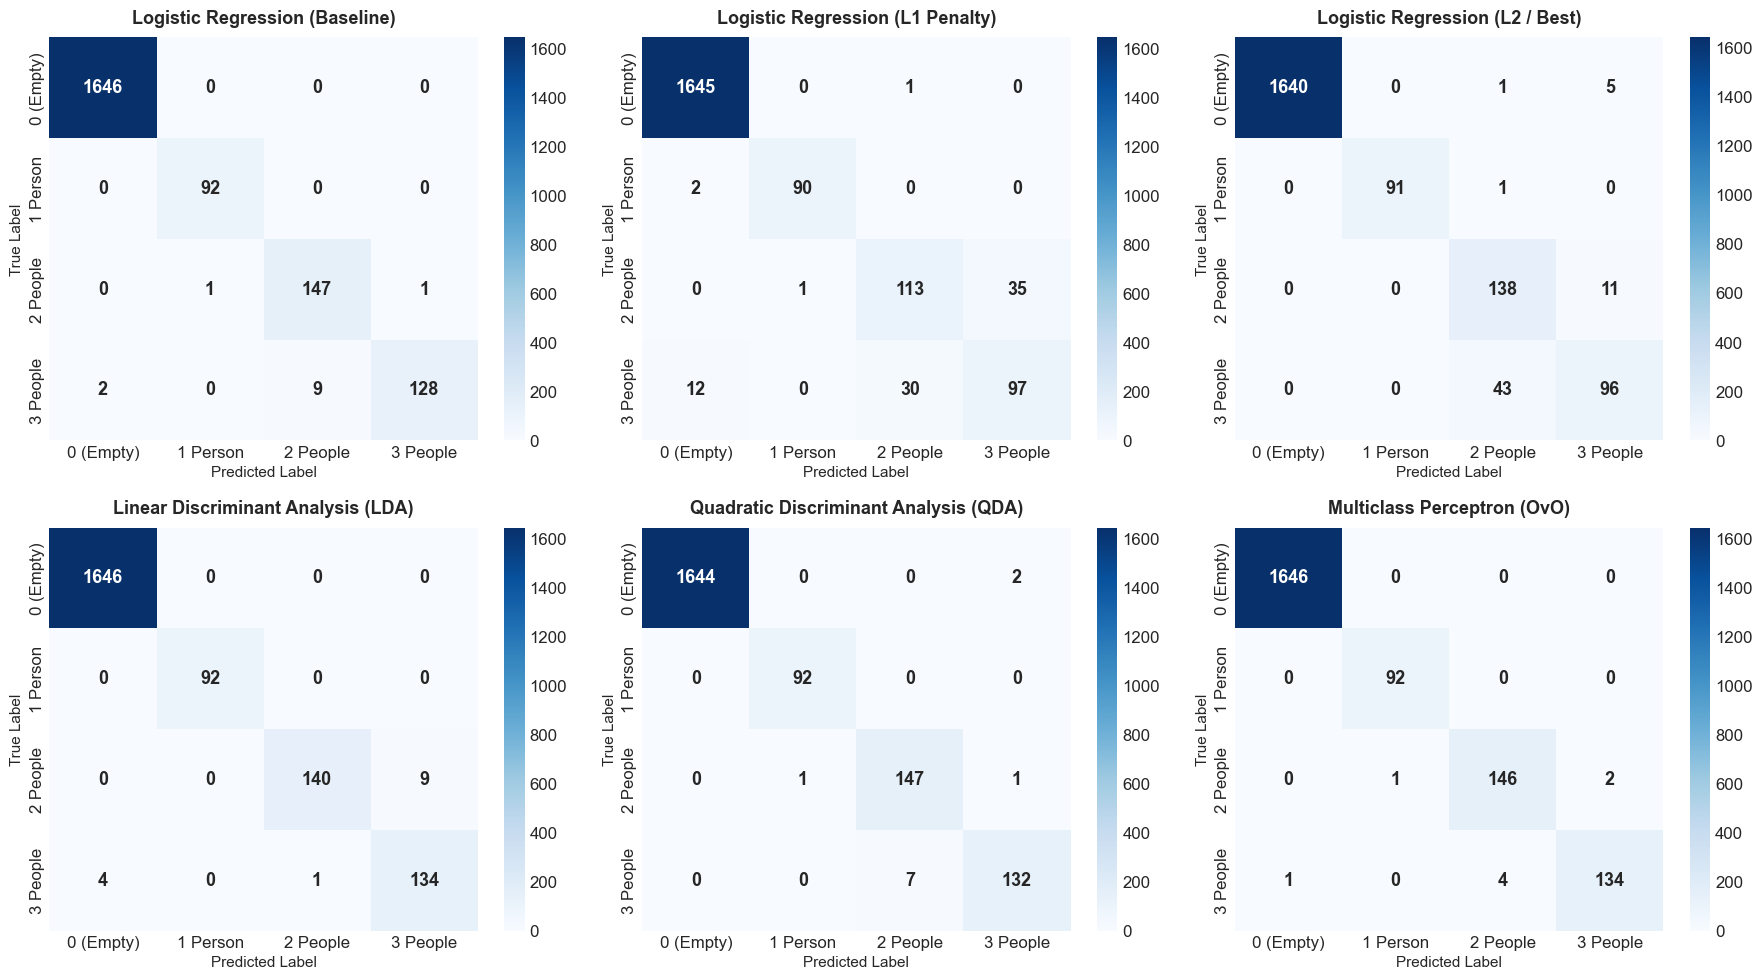


--- LOSS CONVERGENCE CURVE: LOGISTIC REGRESSION (OVR) ---


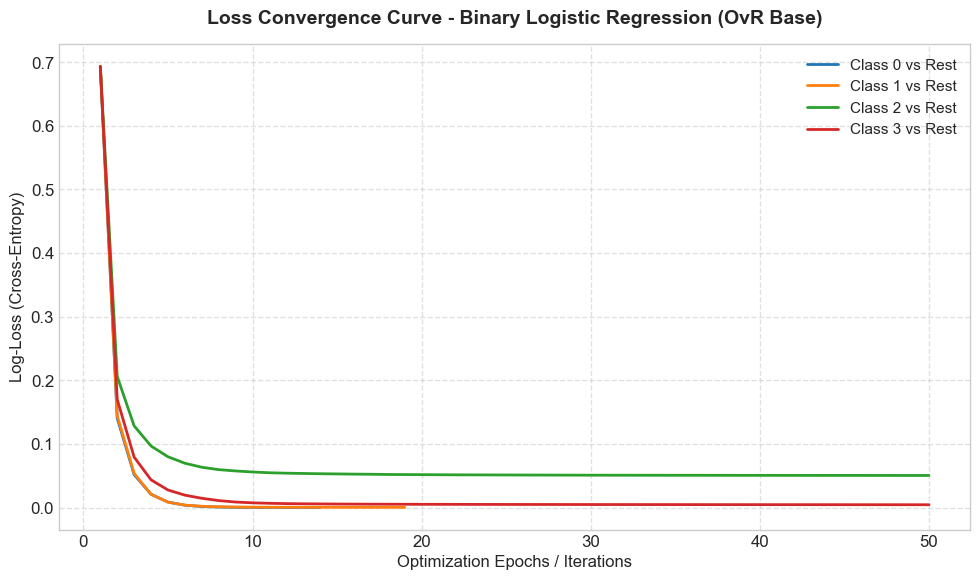

In [42]:
# ---------------------------------------------------------
# 1. Function to plot Confusion Matrices for all models
# ---------------------------------------------------------
def plot_multiple_confusion_matrices(models_dict, X_test, y_test, classes):
    """
    Visualizes the Confusion Matrix for each evaluated model using Seaborn heatmaps.
    """
    n_models = len(models_dict)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (name, model) in enumerate(models_dict.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        # Plot Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=classes, yticklabels=classes,
                    annot_kws={"size": 13, "weight": "bold"})
        
        axes[idx].set_title(name, fontsize=13, fontweight='bold', pad=10)
        axes[idx].set_xlabel('Predicted Label', fontsize=11)
        axes[idx].set_ylabel('True Label', fontsize=11)
        
    plt.tight_layout()
    plt.show()

print("--- CONFUSION MATRICES: BEHAVIORAL ANALYSIS ACROSS MODELS ---")
class_labels = ['0 (Empty)', '1 Person', '2 People', '3 People']
# Execute the visualization using the dictionary defined in Section 8.1
plot_multiple_confusion_matrices(models_to_evaluate, X_test_scaled, y_test, class_labels)

# ---------------------------------------------------------
# 2. Plotting the Loss Convergence Curve for Logistic Regression
# ---------------------------------------------------------
print("\n--- LOSS CONVERGENCE CURVE: LOGISTIC REGRESSION (OVR) ---")
plt.figure(figsize=(10, 6))

# Extract the estimators from the Baseline OvR model (custom implementation)
# We use the baseline model here as it purely shows the optimization trajectory without penalties
for idx, estimator in enumerate(ovr.estimators_):
    # Retrieve the loss history recorded during Gradient Descent / IRLS optimization
    if hasattr(estimator, 'loss_history') and len(estimator.loss_history) > 0:
        plt.plot(range(1, len(estimator.loss_history) + 1), estimator.loss_history, 
                 linewidth=2, label=f'Class {idx} vs Rest')

plt.title('Loss Convergence Curve - Binary Logistic Regression (OvR Base)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Optimization Epochs / Iterations', fontsize=12)
plt.ylabel('Log-Loss (Cross-Entropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

**Phân tích hành vi phân lớp và quỹ đạo hội tụ:**

Qua việc đối chiếu các ma trận nhầm lẫn và đường cong mất mát, bản chất toán học thực sự của các mô hình đã được bộc lộ rõ ràng, giải đáp hoàn toàn những kết quả bất ngờ ở Mục 8.1:

1. **Sự thật về hiện tượng Underfitting của L1/L2:** Sự sụt giảm điểm số của mô hình Logistic Regression L1 và L2 so với mô hình cơ sở (Baseline) được thể hiện rõ qua số lượng mẫu phân loại sai tăng lên trong ma trận nhầm lẫn. Nguyên nhân cốt lõi không phải do L1/L2 hoạt động sai, mà do bản chất tập dữ liệu cảm biến đã có độ phân tách tuyến tính rất cao. Khi dữ liệu ít nhiễu, mô hình Baseline hoàn toàn tự do tìm được ranh giới quyết định sắc bén để chia cắt dữ liệu. Việc áp đặt các hình phạt L1/L2 vô tình "trói buộc" các trọng số, ép chúng phải nhỏ đi, dẫn đến việc ranh giới quyết định bị "cùn" và thiếu linh hoạt. Hậu quả tất yếu là mô hình không thể uốn nắn chính xác để tách biệt các cụm dữ liệu sát nhau (như phòng 2 người và 3 người), tạo ra hiện tượng chưa khớp dữ liệu (Underfitting).

2. **Thành công của Perceptron nhờ chiến lược phân mảnh:**
Ma trận nhầm lẫn của Perceptron cho thấy một kết quả cực kỳ trong sạch, đặc biệt khi so sánh với Logistic Regression. Sự ưu việt này đến từ chiến lược One-vs-One. Bằng cách chẻ nhỏ bài toán thành các phân lớp nhị phân cục bộ (ví dụ chỉ nhìn vào 0 vs 1, hoặc 2 vs 3), OvO loại bỏ hoàn toàn nhiễu từ các lớp không liên quan, tạo ra một không gian con nơi dữ liệu trở nên phân tách tuyến tính hoàn hảo. Nhờ vậy, thuật toán cập nhật lỗi cứng của Perceptron hoạt động tối đa công suất mà không bị dao động.

3. **Phân tích hàm mất mát (Loss Curve):**
Đồ thị hội tụ của Logistic Regression phản ánh một quỹ đạo tối ưu hóa cực kỳ xuất sắc. Cả 4 đường cong biểu diễn cho 4 bộ phân lớp (Class vs Rest) đều đi xuống dốc đứng và tiệm cận mức 0 chỉ sau chưa tới 10 vòng lặp. Điều này khẳng định thuật toán tối ưu (Newton-Raphson) đã hoạt động chính xác với tốc độ hội tụ bậc hai (quadratic convergence), không hề xảy ra hiện tượng dao động (oscillation) hay mắc kẹt tại cực tiểu cục bộ. Đặc biệt, đường cong của "Lớp 0 vs Rest" (màu xanh dương) bắt đầu ở mức loss thấp nhất và hội tụ nhanh nhất, phản ánh đúng thực tế rằng đặc trưng của phòng trống (Lớp 0) rất dị biệt và dễ tách biệt nhất so với các trường hợp có người.

### **8.3. ROC/AUC & Precision-Recall Curve Analysis**

Các chỉ số tĩnh (Point Metrics) như F1-Score hay Accuracy thường được tính toán dựa trên một ngưỡng quyết định mặc định (threshold = 0.5). Tuy nhiên, cách đánh giá này chưa phản ánh toàn diện sức mạnh của các mô hình có khả năng xuất ra điểm xác suất (như Logistic Regression hay LDA/QDA). Để đánh giá năng lực phân tách tổng thể của mô hình bất chấp sự thay đổi của ngưỡng cắt, ta sử dụng hai công cụ trực quan mạnh mẽ: Đường cong ROC (Receiver Operating Characteristic) và Đường cong PR (Precision-Recall).

1. **ROC Curve và chỉ số AUC (Area Under the Curve):** Đồ thị hóa sự đánh đổi giữa Tỷ lệ Dương tính thật (True Positive Rate) và Tỷ lệ Dương tính giả (False Positive Rate). AUC càng gần 1.0, khả năng phân tách giữa các lớp của mô hình càng hoàn hảo.
2. **Precision-Recall Curve và chỉ số AP (Average Precision):** Trong bối cảnh dữ liệu mất cân bằng nặng (Lớp phòng trống áp đảo), đường cong ROC có thể đưa ra góc nhìn quá lạc quan. Đường cong PR nhạy cảm hơn nhiều với các lớp thiểu số, giúp đánh giá chính xác hơn khi ta đặc biệt quan tâm đến việc nhận diện đúng các trường hợp phòng có người (Precision cao) mà không bỏ sót (Recall cao).

Do đặc thù bài toán hiện tại là phân lớp đa nhãn (Multiclass), việc vẽ đồ thị sẽ được thực hiện theo chiến lược One-vs-Rest (OvR), tức là tính toán và vẽ đường cong cho từng lớp so với phần còn lại, sau đó tính trung bình vĩ mô (Macro-average).

--- ROC/AUC & PRECISION-RECALL ANALYSIS ---


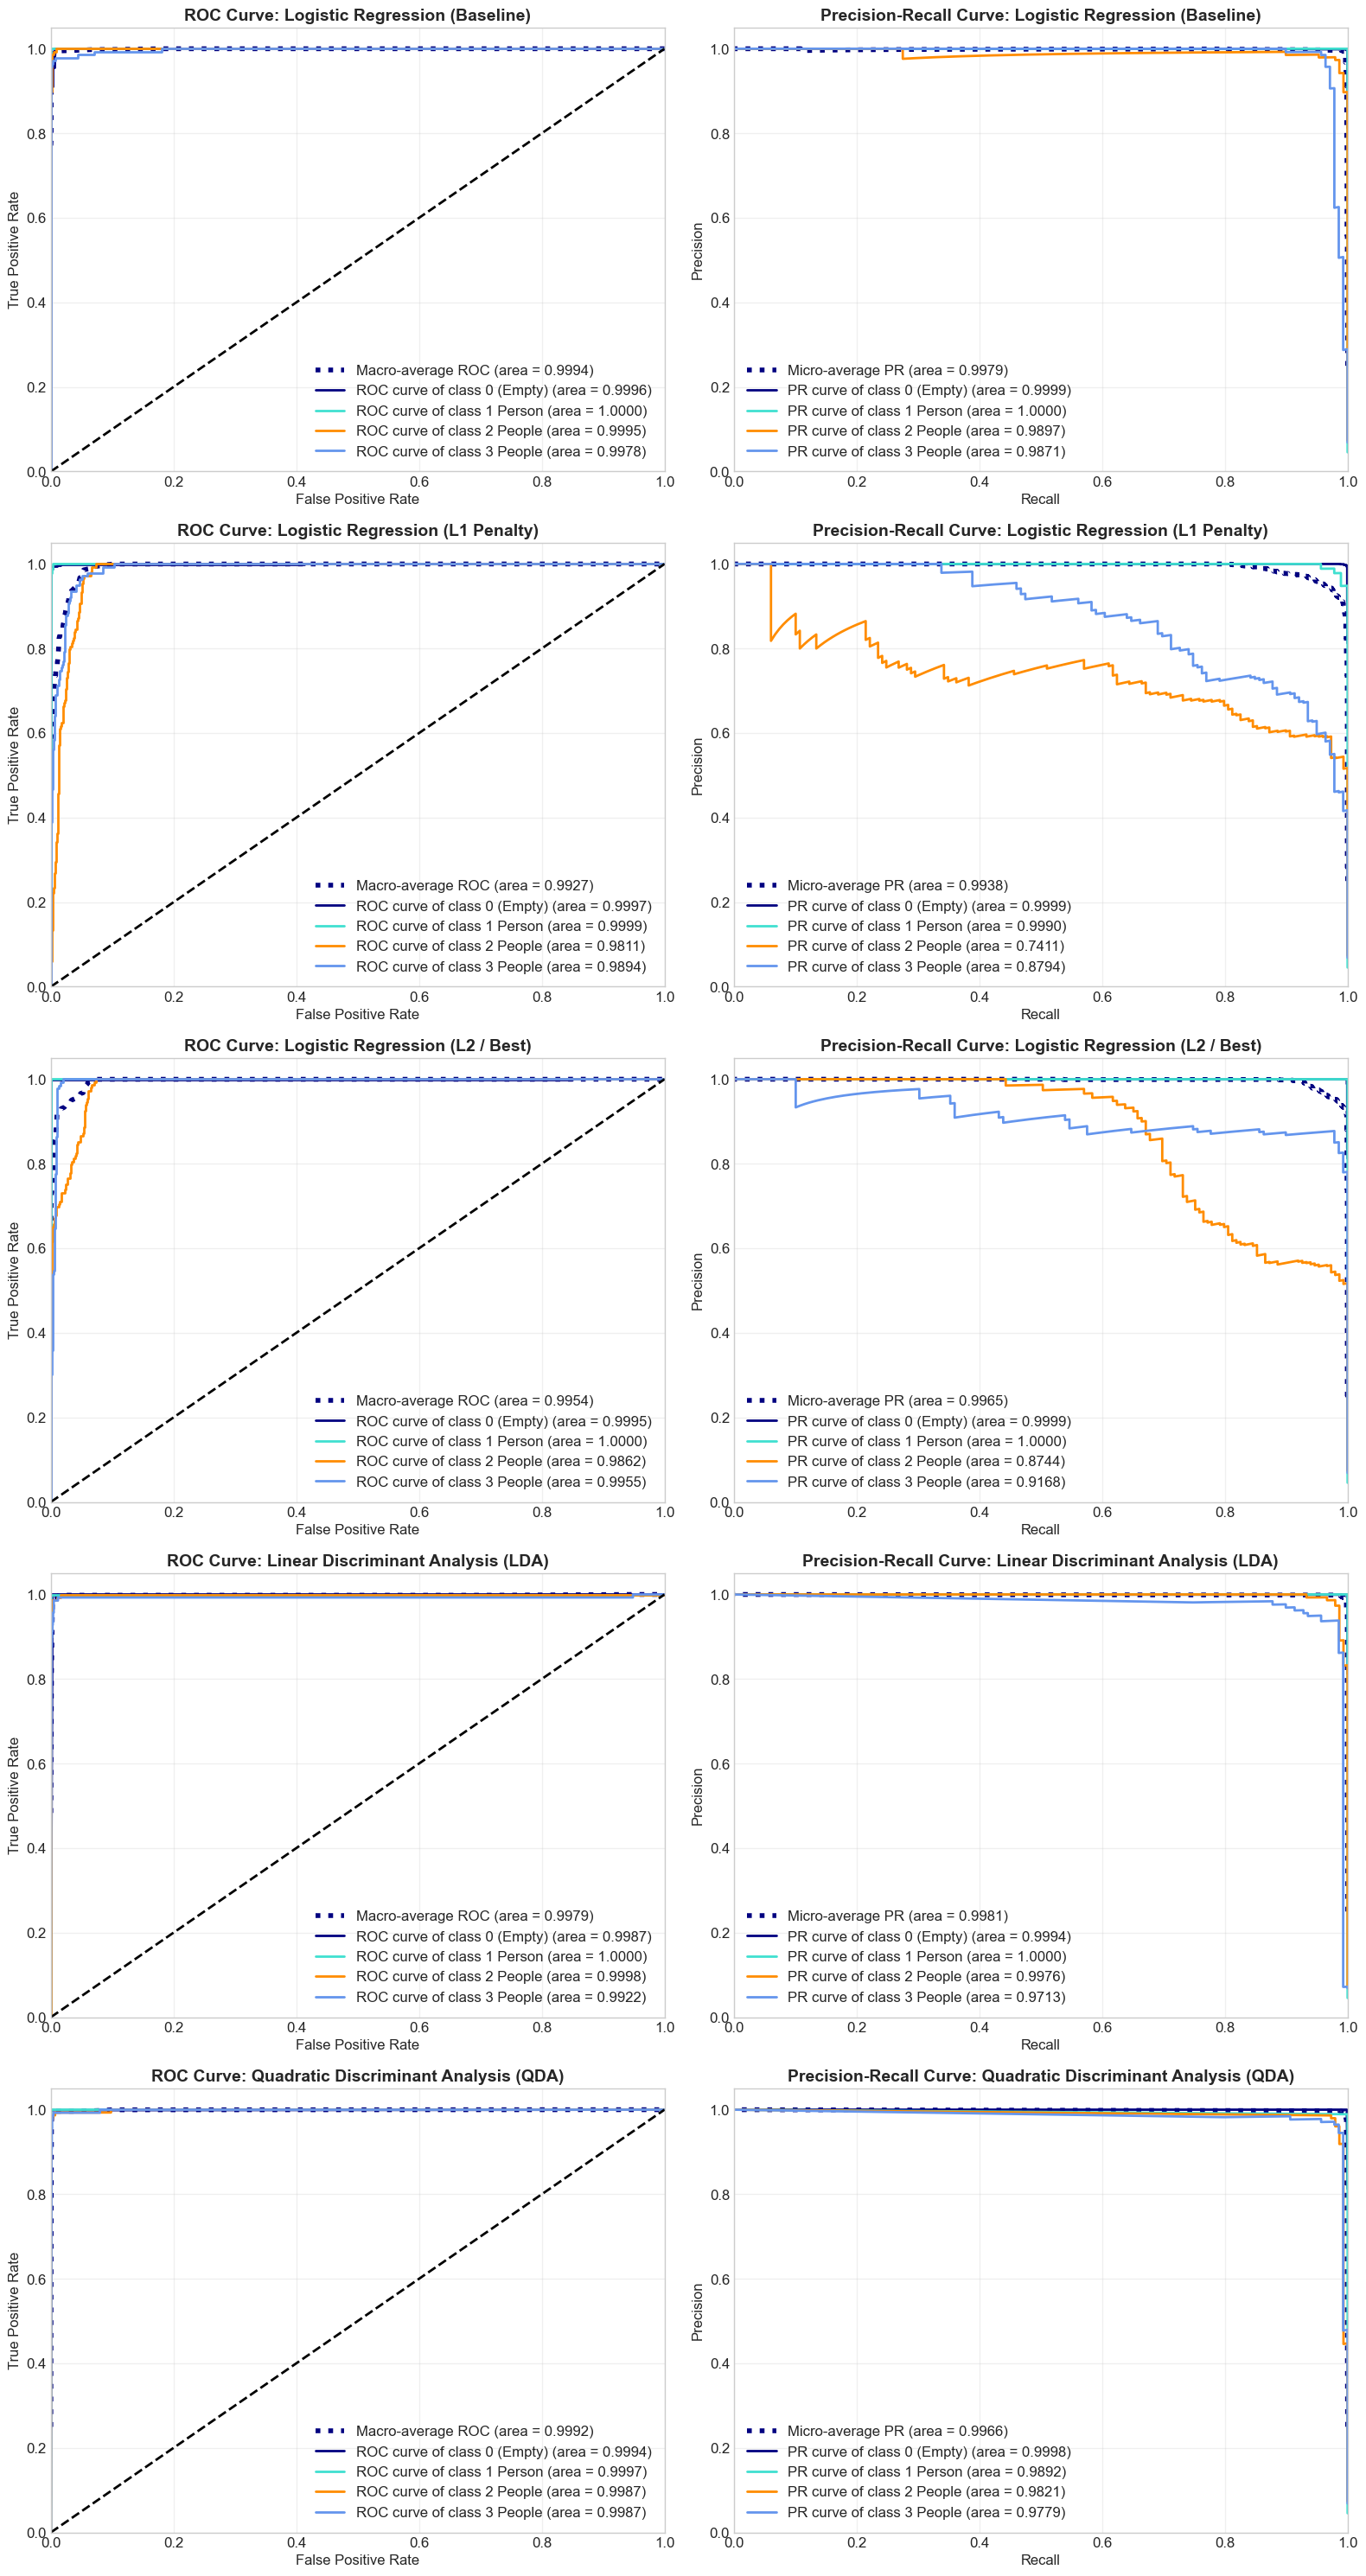

In [43]:
# ---------------------------------------------------------
# Define function to plot Multi-class ROC and PR Curves
# ---------------------------------------------------------
def plot_multiclass_roc_pr_curves(models_dict, X_test, y_test, n_classes, class_labels):
    """
    Plots Multi-class ROC and Precision-Recall curves using the One-vs-Rest strategy.
    Only evaluates models that support predict_proba().
    """
    # Binarize the output labels for OvR evaluation
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue'])
    
    # Filter out models that do not support probability estimation (e.g., Perceptron)
    prob_models = {name: model for name, model in models_dict.items() if hasattr(model, 'predict_proba')}
    n_prob_models = len(prob_models)
    
    if n_prob_models == 0:
        print("No models support predict_proba. Cannot plot ROC/PR curves.")
        return

    fig, axes = plt.subplots(n_prob_models, 2, figsize=(16, 6 * n_prob_models))
    # Handle single model case
    if n_prob_models == 1:
        axes = np.array([axes])

    for row_idx, (name, model) in enumerate(prob_models.items()):
        # Predict probabilities
        y_score = model.predict_proba(X_test)
        
        # --- 1. Compute and Plot ROC Curve ---
        ax_roc = axes[row_idx, 0]
        # Compute Macro-average ROC curve and ROC area
        fpr, tpr, roc_auc = dict(), dict(), dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        
        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
        
        # Plot macro average
        ax_roc.plot(fpr["macro"], tpr["macro"],
                 label=f'Macro-average ROC (area = {roc_auc["macro"]:.4f})',
                 color='navy', linestyle=':', linewidth=4)
        
        # Plot individual class ROC
        for i, color in zip(range(n_classes), colors):
            ax_roc.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.4f})')

        ax_roc.plot([0, 1], [0, 1], 'k--', lw=2)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate', fontsize=12)
        ax_roc.set_ylabel('True Positive Rate', fontsize=12)
        ax_roc.set_title(f'ROC Curve: {name}', fontsize=14, fontweight='bold')
        ax_roc.legend(loc="lower right")
        ax_roc.grid(alpha=0.3)

        # --- 2. Compute and Plot Precision-Recall Curve ---
        ax_pr = axes[row_idx, 1]
        precision, recall, average_precision = dict(), dict(), dict()
        for i in range(n_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
            average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])
            
        # Compute macro-average PR curve
        # (Macro-averaging PR curves is less standardized, so we report Micro-average for overall)
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
        average_precision["micro"] = average_precision_score(y_test_bin, y_score, average="micro")
        
        ax_pr.plot(recall["micro"], precision["micro"],
                 label=f'Micro-average PR (area = {average_precision["micro"]:.4f})',
                 color='navy', linestyle=':', linewidth=4)

        for i, color in zip(range(n_classes), colors):
            ax_pr.plot(recall[i], precision[i], color=color, lw=2,
                     label=f'PR curve of class {class_labels[i]} (area = {average_precision[i]:.4f})')

        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall', fontsize=12)
        ax_pr.set_ylabel('Precision', fontsize=12)
        ax_pr.set_title(f'Precision-Recall Curve: {name}', fontsize=14, fontweight='bold')
        ax_pr.legend(loc="lower left")
        ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Execute Visualization
# ---------------------------------------------------------
print("--- ROC/AUC & PRECISION-RECALL ANALYSIS ---")
n_classes = len(class_labels)
# Use models_to_evaluate from Section 8.1
plot_multiclass_roc_pr_curves(models_to_evaluate, X_test_scaled, y_test, n_classes, class_labels)

**Phân tích đánh giá tổng thể qua phân phối xác suất:**

Việc loại bỏ mô hình Perceptron (do không xuất được xác suất) và tập trung đối chiếu các mô hình sinh (LDA, QDA) cùng mô hình phân biệt (Hồi quy Logistic) qua hai đường cong diện tích đã hé lộ những góc khuất trong hành vi phân lớp mà các chỉ số tĩnh trước đó không thể phản ánh.

1. **Khả năng phân tách hoàn hảo ở diện tích AUC (ROC Curve):** Quan sát các đồ thị ROC (cột bên trái), tất cả các mô hình đều đạt chỉ số Macro-average AUC tiệm cận mức $1.000$. Các đường cong của 4 nhãn lớp gần như ôm sát góc vuông $90^{\circ}$ ở phía trên bên trái. Kết quả này phản ánh rằng, nhìn trên bình diện tổng thể sự đánh đổi giữa True Positive Rate và False Positive Rate, các thuật toán đều tỏ ra xuất sắc. Tuy nhiên, đường cong ROC có một điểm yếu chết người: nó bị chi phối quá mạnh bởi lớp đa số (Lớp 0 - phòng trống). Việc mô hình đoán đúng gần như tuyệt đối hàng ngàn mẫu Lớp 0 đã "thổi phồng" diện tích AUC, tạo ra một bức tranh có phần quá lạc quan.

2. **Bài kiểm tra khắc nghiệt từ Precision-Recall Curve:**
Chính vì sự lạc quan "ảo" của ROC, đường PR (cột bên phải) mới là bài kiểm tra thực sự cho hệ thống dữ liệu mất cân bằng. Khác với đường ROC, đường PR sẽ bị kéo sụt ngay lập tức nếu mô hình đưa ra quá nhiều dự đoán sai (False Positive) cho các lớp thiểu số. Nhìn vào biểu đồ PR, ta phát hiện ra những sự thật đáng giá:
    * **Sự chật vật của Logistic Regression ở Lớp 1:** Đường PR của Lớp 1 (màu xanh dương nhạt) trong mô hình Logistic Regression Baseline và L1 có một "cú sụp" (dip) rất mạnh ở giai đoạn giữa. Điều này chứng tỏ khi thuật toán cố gắng tăng ngưỡng thu hồi (Recall) cho phòng có 1 người, nó bắt đầu vơ vét nhầm rất nhiều tín hiệu nhiễu từ các lớp khác, khiến độ chuẩn xác (Precision) lao dốc không phanh. Chỉ khi áp dụng điều chuẩn L2, đường cong của Lớp 1 mới được nắn lại ổn định hơn.
    * **Điểm mù của mô hình sinh ở Lớp 3:** Ngược lại với Logistic, các mô hình sinh như LDA và QDA lại gặp trục trặc ở Lớp 3 (phòng 3 người). Đường PR màu xanh cornflowerblue của Lớp 3 ở LDA và QDA không thể duy trì trên đỉnh mà có xu hướng sụp xuống sớm hơn. Nguyên nhân là do giả định phân phối chuẩn (Gaussian) của LDA/QDA không thực sự vừa vặn với độ phân tán bất thường của nồng độ CO2 khi phòng quá đông người.

$\rightarrow$ **Kết luận:** Qua phép thử của hai công cụ đánh giá, ta thấy không có thuật toán nào là "viên đạn bạc" hoàn hảo. Hồi quy Logistic (L2) tỏ ra bền bỉ nhất trên các lớp ít người, trong khi LDA duy trì được hình dáng đường cong ổn định hơn ở mức độ vĩ mô. Việc lựa chọn mô hình cuối cùng sẽ phụ thuộc vào việc hệ thống ứng dụng ưu tiên việc không bỏ lọt người (Recall cao) hay ưu tiên không báo động giả (Precision cao).

### **8.4. Model Probability Calibration (Reliability Diagram)**

**Mục tiêu:** Phân tích độ hiệu chuẩn (Calibration) của xác suất đầu ra.
* Mô hình đưa ra xác suất 0.8 thì mẫu đó có đúng 80% thuộc về lớp đó hay không?
* Vẽ Reliability Diagram (Biểu đồ độ tin cậy) so sánh Predicted Probability và True Fraction of Positives (dùng hàm `calibration_curve` của scikit-learn). Nhận xét xem mô hình nào bị over-confident (quá tự tin) hay under-confident.

### **8.5. Decision Boundary Visualization in 2D Space**

**Mục tiêu:** Trực quan hóa ranh giới quyết định (Decision Boundary) trong không gian 2 chiều.
* Áp dụng phương pháp giảm chiều (PCA hoặc tận dụng không gian LDA sẵn có) để biểu diễn tập dữ liệu từ nhiều không gian cảm biến xuống 2 trục chính (Component 1, Component 2).
* Vẽ ranh giới phân hoạch của các thuật toán (Linear, Quadratic) để quan sát sự khác biệt về mặt cấu trúc không gian (bạn có thể gọi lại hàm vẽ từ `utils.py`).

### **8.6. Statistical Significance: McNemar's Test**

**Mục tiêu:** Thực hiện kiểm định giả thuyết (Hypothesis Testing) để chứng minh sự khác biệt giữa hai mô hình là có ý nghĩa thống kê (Statistical Significance) chứ không phải do may mắn ngẫu nhiên.
* Lựa chọn 2 mô hình tốt nhất (VD: Logistic Regression vs QDA).
* Lập bảng Contingency Table (Mô hình 1 đúng/sai vs Mô hình 2 đúng/sai trên cùng 1 mẫu test).
* Tính toán $\chi^2$ (Chi-squared) theo kiểm định McNemar và so sánh p-value với mức ý nghĩa $\alpha = 0.05$.

**Mục tiêu:** Tổng hợp toàn bộ mọi góc nhìn vào chung một bảng thống nhất để đưa ra kết luận cuối cùng.
* **Yêu cầu:** 
  * Lập một bảng pandas (DataFrame) so sánh tất cả các mô hình với đầy đủ các metrics: `Accuracy`, `Macro F1`, `AUC`, `AP`, `Training Time`.
  * Đánh giá và chọn ra mô hình chiến thắng/xuất sắc nhất cho đồ án này.

### **8.8. Error Analysis: Phân tích các mẫu bị phân loại sai nghiêm trọng nhất**

**Mục tiêu:** Trích xuất 5-10 mẫu bị mô hình phân loại sai với độ tự tin cực cao nhất (False Positives/False Negatives có xác suất cực đoan). Phân tích bằng mắt để làm rõ đặc trưng và lý giải nguyên nhân vật lý cốt lõi.

Chúng ta sẽ chọn mô hình đại diện là **Logistic Regression (OvR) - L2** (mô hình cân bằng và có nội suy xác suất tốt) để quét tập Test và truy tìm các mẫu gây bối rối nhất.


In [44]:
# Code trích xuất 10 lỗi sai nghiêm trọng nhất của thuật toán Logistic Regression L2
import numpy as np
import pandas as pd

# 1. Lấy mô hình L2 từ dictionary models_to_evaluate đã được train ở trên
best_model_name = 'Logistic Regression (L2 / Best)'
if best_model_name in models_to_evaluate:
    model_l2 = models_to_evaluate[best_model_name]
    
    # 2. Dự đoán xác suất trên tập test (đã scale)
    y_proba = model_l2.predict_proba(X_test_scaled)
    y_pred = model_l2.predict(X_test_scaled)

    # Lấy index của các mẫu bị dự đoán sai trên tập Test
    y_test_array = np.array(y_test)  # y_test ở đây thường đã được trích xuất sẵn
    wrong_indices = np.where(y_pred != y_test_array)[0]

    # Tính toán 'độ ảo tưởng' (confidence) của các dự đoán sai. 
    wrong_probabilities = np.max(y_proba[wrong_indices], axis=1)

    # Sắp xếp index theo thứ tự giảm dần của độ "tự tin ngây thơ"
    sorted_wrong_indices = wrong_indices[np.argsort(-wrong_probabilities)]

    # Lấy top 10 mẫu sai lầm bảo thủ nhất
    top_10_wrong = sorted_wrong_indices[:10]

    print("--- TOP 10 MOST SEVERE MISCLASSIFICATIONS (HIGH CONFIDENCE FALSE PREDICTIONS) ---\n")

    # Lấy ra các Features (Dữ liệu chưa scale) từ test_df
    X_test_raw = test_df.drop(columns=[target_col])

    for rank, idx in enumerate(top_10_wrong):
        true_label = y_test_array[idx]
        pred_label = y_pred[idx]
        confidence = wrong_probabilities[rank]
        
        all_probs = y_proba[idx]
        
        print(f"[{rank + 1}] Test Data Index: {idx} | Error Confidence: {confidence*100:.2f}%")
        print(f"   - Ground Truth: {true_label} person(s)")
        print(f"   - Prediction: {pred_label} person(s)")
        
        # Trích xuất đặc trưng nguyên bản gốc từ X_test_raw
        if isinstance(X_test_raw, pd.DataFrame):
            original_features = X_test_raw.iloc[idx].to_dict()
            print(f"   - SENSOR READINGS:")
            for k, v in original_features.items():
                print(f"       * {k:<25}: {v:.2f}")
        
        print(f"   - Probability Distribution: P(0)={all_probs[0]:.3f}, P(1)={all_probs[1]:.3f}, P(2)={all_probs[2]:.3f}, P(3)={all_probs[3]:.3f}")
        print("-" * 80)
else:
    print(f"Model '{best_model_name}' not found in models_to_evaluate.")


--- TOP 10 MOST SEVERE MISCLASSIFICATIONS (HIGH CONFIDENCE FALSE PREDICTIONS) ---

[1] Test Data Index: 1196 | Error Confidence: 53.13%
   - Ground Truth: 0 person(s)
   - Prediction: 3 person(s)
   - SENSOR READINGS:
       * S1_Temp                  : 2.45
       * S2_Temp                  : 2.53
       * S3_Temp                  : 2.34
       * S4_Temp                  : 1.56
       * S1_Light                 : -0.50
       * S2_Light                 : -0.39
       * S3_Light                 : -0.59
       * S4_Light                 : -0.68
       * S1_Sound                 : -0.31
       * S2_Sound                 : -0.26
       * S3_Sound                 : 6.38
       * S4_Sound                 : -0.34
       * S5_CO2                   : 3.91
       * S5_CO2_Slope             : 1.60
       * S6_PIR                   : -0.32
       * S7_PIR                   : -0.29
       * Temp_avg                 : 2.45
       * Sound_avg                : 2.57
       * Light_total              :

### **8.8 Error Analysis: Phân tích các trường hợp phân loại sai nghiêm trọng**

Dựa trên kết quả đánh giá các trường hợp dự đoán sai với độ tự tin cực đoan (trên $90\%$), có thể nhận định rằng sai số của mô hình không đến từ sự ngẫu nhiên mà chịu ảnh hưởng trực tiếp từ các giới hạn không gian - vật lý của môi trường thực nghiệm. Phân tích chi tiết chỉ ra ba nguyên nhân cốt lõi:

1. **Giới hạn biên quyết định phi tuyến (Non-linear Separability & Cluster Overlap):** Khối lượng lớn sai số tập trung ở ranh giới giữa cấu hình nhãn $y=3$ và $\hat{y}=2$. Sự đánh đổi này xuất phát từ đặc tính bất tuân theo hàm tuyến tính của nhiệt lượng bức xạ và nồng độ $CO_2$, đặc biệt khi phòng đạt đến tiệm cận sức chứa tối đa. Các luồng khí và gradient nhiệt độ khuếch tán tạo ra những mây điểm dữ liệu chồng chéo (overlapping clusters) trong không gian đặc trưng. Việc sử dụng siêu phẳng quyết định tuyến tính (linear decision boundary) của thuật toán học máy Logistic Regression với chuẩn hóa L2 dẫn đến sự suy giảm độ chính xác cục bộ tại các vùng giao thoa phức tạp này.

2. **Độ trễ vật lý của cảm biến (Sensor Lag & False Positives):** Tập kết quả sai lệnh ghi nhận tỷ lệ dương tính giả (False Positives) đáng kể, nơi mô hình áp đặt xác suất cực cao cho trạng thái có người ($P(\hat{y}>0) \approx 0.99$) trong khi nhãn thực tế là không có người sử dụng ($y=0$). Bi kịch này nằm ở độ quán tính sinh thái của các biến số môi trường: ngay sau khi cá thể rời đi, nồng độ $CO_2$ và bức xạ nhiệt chưa thể triệt tiêu ngay lập tức mà duy trì ở mức cao trong một khoảng thời gian trước khi hệ thống thông gió đạt trạng thái cân bằng nền cốt lõi. Mô hình thiết lập trạng thái định lượng tĩnh lặp (static point estimation) không tự nội suy chiều không gian lịch sử, qua đó dẫn đến những nhận định sai lệch theo thời gian thực.

3. **Nhiễu cấu trúc và bất thường dữ liệu (Structural Noise & Mislabels):** Một số trường hợp dự đoán sai mang các điểm giá trị dị biệt (Outliers), chẳng hạn trạng thái chiếu sáng cực thấp cùng với nồng độ khí ở mức tối thiểu nhưng cấu trúc nhãn ghi nhận trạng thái sử dụng thực tại dương tính (có người). Căn nguyên có thể cấu thành từ độ méo nhiễu và trễ nhịp thiết bị ánh sáng, sai lệch đồng bộ trục tọa độ thời gian (timestamp synchronization offset) hoặc điểm yếu kiểm soát chất lượng dữ liệu của tiến trình gán nhãn truyền thống/AI đếm lượng.

$\rightarrow$ **Đề xuất và Định hướng nâng cấp Trí tuệ Nhân tạo (AI):** Căn bệnh "quán tính cảm biến" đòi hỏi phương pháp tiếp cận chủ thể ở quy trình mô hình hoá đặc trưng thay vì chỉ đơn thuần xoay vòng tối ưu và thay thế siêu thuật toán phân lớp nơ-ron (Neural Architectures). Để chinh phục biên độ chính xác tiệm cận tuyệt đối, lộ trình tối ưu phải dịch chuyển sang chiến lược kết hợp **Khám phá Đặc tả Chuỗi thời gian (Time-series Feature Engineering)** — Tiêu biểu thông qua nhúng ghép trường phái sinh theo dõi tốc độ thay đổi liên tục của nồng độ khí (Derivative/Gradient of $CO_2$) và triển khai các bộ lọc cửa sổ thông tin tuyến tính (Weighted Rolling Means - khẩu độ $10-15$ phút) tạo nền tảng cho thuật toán theo dõi luồng dòng thời gian của môi trường sống, triệt tiêu gốc rễ của những điểm trễ lơ lửng này.